In [1]:
# ============================================================
# PHASE 12 — RANDOM-GENE-SET BIOLOGICAL ENRICHMENT BASELINE
# ============================================================
# Goal:
# 1. Test whether observed top-ranked biological theme enrichment
#    is stronger than expected by chance.
# 2. Compare model top-50/top-100 gene lists against random gene sets
#    sampled from the same candidate universe.
# 3. Produce empirical p-values for curated biological themes:
#    - mitochondrial_function
#    - oxidative_phosphorylation
#    - known_t2d_gwas_or_monogenic
#    - beta_cell_biology
#    - glucose_metabolism
#    - insulin_signalling
#    - pancreatic_development
#    - lipid_metabolism
# 4. Optional: run g:Profiler random baseline on fewer permutations.
# ============================================================

import warnings
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 250)
pd.set_option("display.max_colwidth", 300)

SEED = 42
rng = np.random.default_rng(SEED)

import os
from pathlib import Path
import pandas as pd
from google.colab import drive

try:
    drive.mount('/content/drive')
except ValueError:
    print("Drive đã được kết nối từ trước.")

PROJECT_DIR = Path("/content/drive/MyDrive/Project_Protein")

PHASE7_DIR = PROJECT_DIR / "model" / "phase7_statistical_evidence"
PHASE8_DIR = PROJECT_DIR / "model" / "phase8_expanded_biological_validation"
PHASE9_DIR = PROJECT_DIR / "model" / "phase9_dnabert2_behaviour_deep_dive"
PHASE10_DIR = PROJECT_DIR / "model" / "phase10_final_modality_contribution_visualization"
PHASE11_DIR = PROJECT_DIR / "model" / "phase11_repeated_split_seed_robustness"

PHASE8_RESULT_DIR = PHASE8_DIR / "results"
PHASE9_RESULT_DIR = PHASE9_DIR / "results"
PHASE10_RESULT_DIR = PHASE10_DIR / "results"
PHASE11_RESULT_DIR = PHASE11_DIR / "results"

PHASE12_DIR = PROJECT_DIR / "model" / "phase12_random_gene_set_enrichment_baseline"
RESULT_DIR = PHASE12_DIR / "results"
FIGURE_DIR = PHASE12_DIR / "figures"
EXCEL_DIR = PHASE12_DIR / "excel"
REPORT_DIR = PHASE12_DIR / "reports"
GENE_LIST_DIR = PHASE12_DIR / "gene_lists"

for folder in [PHASE12_DIR, RESULT_DIR, FIGURE_DIR, EXCEL_DIR, REPORT_DIR, GENE_LIST_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

print("Phase 12 output:", PHASE12_DIR)

Mounted at /content/drive
Phase 12 output: /content/drive/MyDrive/Project_Protein/model/phase12_random_gene_set_enrichment_baseline


In [2]:
# ============================================================
# CONFIGURATION
# ============================================================

# Main random baseline.
# 1000 is good for report. Use 200 first for quick debug if needed.
N_RANDOM_PERMUTATIONS = 1000

# Top-ranked list sizes to test
TOP_N_LIST = [50, 100]

# Same seed every time for reproducibility
RANDOM_SEED = 42
rng = np.random.default_rng(RANDOM_SEED)

# Empirical p-value correction:
# Use +1 numerator/denominator to avoid zero p-values.
USE_PLUS_ONE_PVALUE = True

# Optional g:Profiler baseline can be slow.
# Recommended first run: False.
RUN_GPROFILER_RANDOM_BASELINE = False

# If RUN_GPROFILER_RANDOM_BASELINE=True, keep small number.
N_GPROFILER_RANDOM_PERMUTATIONS = 100

print("N_RANDOM_PERMUTATIONS:", N_RANDOM_PERMUTATIONS)
print("TOP_N_LIST:", TOP_N_LIST)
print("RUN_GPROFILER_RANDOM_BASELINE:", RUN_GPROFILER_RANDOM_BASELINE)

N_RANDOM_PERMUTATIONS: 1000
TOP_N_LIST: [50, 100]
RUN_GPROFILER_RANDOM_BASELINE: False


In [3]:
# ============================================================
# HELPER FUNCTIONS
# ============================================================

def normalize_gene_symbol(x):
    if pd.isna(x):
        return ""
    return str(x).strip().upper()


def round_numeric_columns(df, digits=4):
    df = df.copy()
    for col in df.columns:
        if pd.api.types.is_float_dtype(df[col]):
            df[col] = df[col].round(digits)
    return df


def read_csv_required(path):
    path = Path(path)
    assert path.exists(), f"Missing required file: {path}"
    print("Loaded:", path)
    return pd.read_csv(path)


def get_gene_set_from_df(df, gene_col="gene_symbol_upper"):
    genes = (
        df[gene_col]
        .dropna()
        .astype(str)
        .map(normalize_gene_symbol)
    )
    genes = genes[genes != ""]
    return set(genes.tolist())


def count_theme_overlap(gene_set, theme_gene_set):
    return len(set(gene_set) & set(theme_gene_set))


def empirical_p_value_greater_equal(observed, random_values, plus_one=True):
    random_values = np.asarray(random_values)

    if plus_one:
        return (np.sum(random_values >= observed) + 1) / (len(random_values) + 1)

    return np.mean(random_values >= observed)


def percentile_summary(values):
    values = np.asarray(values)

    return {
        "random_mean": np.mean(values),
        "random_sd": np.std(values, ddof=1),
        "random_median": np.median(values),
        "random_min": np.min(values),
        "random_max": np.max(values),
        "random_p025": np.percentile(values, 2.5),
        "random_p975": np.percentile(values, 97.5),
    }


def gene_list_string(gene_set):
    return ";".join(sorted(list(gene_set)))


def save_gene_list(genes, path):
    genes = sorted([g for g in genes if str(g).strip() != ""])
    with open(path, "w") as f:
        for g in genes:
            f.write(str(g) + "\n")
    print("Saved:", path, "| n =", len(genes))

In [4]:
# ============================================================
# LOAD REQUIRED FILES
# ============================================================

# Phase 8 annotated ranked predictions are the main input.
ranked_files = {
    "Protein_only_ProtBERT_SW": PHASE8_RESULT_DIR / "phase8_annotated_ranked_predictions_Protein_only_ProtBERT_SW.csv",
    "Multimodal_handcrafted": PHASE8_RESULT_DIR / "phase8_annotated_ranked_predictions_Multimodal_handcrafted.csv",
    "Multimodal_DNABERT2": PHASE8_RESULT_DIR / "phase8_annotated_ranked_predictions_Multimodal_DNABERT2.csv",
}

ranked_predictions = {}

for model_key, path in ranked_files.items():
    ranked_predictions[model_key] = read_csv_required(path)

# Optional genomic-only ranked file
genomic_ranked_path = PHASE8_RESULT_DIR / "phase8_annotated_ranked_predictions_Genomic_only_K3K4Basic.csv"

if genomic_ranked_path.exists():
    ranked_predictions["Genomic_only_K3K4Basic"] = pd.read_csv(genomic_ranked_path)
    print("Loaded:", genomic_ranked_path)
else:
    print("Genomic-only ranked predictions not found in Phase 8. It will be skipped for top-list baseline.")

# Phase 8 curated theme overlap table
theme_overlap_df = read_csv_required(
    PHASE8_RESULT_DIR / "phase8_curated_theme_overlap_top50_top100.csv"
)

# Phase 8 enrichment summary
enrichment_summary_df = read_csv_required(
    PHASE8_RESULT_DIR / "phase8_expanded_enrichment_summary_by_gene_list.csv"
)

# Phase 9 movement table for DNABERT-2 moved-in/out lists
movement_master_df = read_csv_required(
    PHASE9_RESULT_DIR / "phase9_movement_master_table_with_themes.csv"
)

# Phase 11 repeated split summary if available
phase11_summary_path = PHASE11_RESULT_DIR / "phase11_repeated_split_mean_sd_summary.csv"

if phase11_summary_path.exists():
    phase11_summary_df = pd.read_csv(phase11_summary_path)
    print("Loaded:", phase11_summary_path)
else:
    phase11_summary_df = pd.DataFrame()
    print("Phase 11 summary not found. Continuing without it.")

# Inspect
for model_key, df in ranked_predictions.items():
    print(model_key, df.shape, df.columns.tolist()[:20])
    display(df.head(3))

Loaded: /content/drive/MyDrive/Project_Protein/model/phase8_expanded_biological_validation/results/phase8_annotated_ranked_predictions_Protein_only_ProtBERT_SW.csv
Loaded: /content/drive/MyDrive/Project_Protein/model/phase8_expanded_biological_validation/results/phase8_annotated_ranked_predictions_Multimodal_handcrafted.csv
Loaded: /content/drive/MyDrive/Project_Protein/model/phase8_expanded_biological_validation/results/phase8_annotated_ranked_predictions_Multimodal_DNABERT2.csv
Loaded: /content/drive/MyDrive/Project_Protein/model/phase8_expanded_biological_validation/results/phase8_annotated_ranked_predictions_Genomic_only_K3K4Basic.csv
Loaded: /content/drive/MyDrive/Project_Protein/model/phase8_expanded_biological_validation/results/phase8_curated_theme_overlap_top50_top100.csv
Loaded: /content/drive/MyDrive/Project_Protein/model/phase8_expanded_biological_validation/results/phase8_expanded_enrichment_summary_by_gene_list.csv
Loaded: /content/drive/MyDrive/Project_Protein/model/phas

,gene_id,gene_symbol_protein,label_protein,protein_row_index,original_protein_split,gene_symbol_genomic,label_genomic,genomic_row_index,original_genomic_split,label_match,label,gene_symbol,true_label,Protein_only_ProtBERT_SW_score,Genomic_only_K3K4Basic_score,Multimodal_handcrafted_score,Multimodal_DNABERT2_score,gene_symbol_upper,model_key,model_display_name,score,pred_label_0p5,error_type_0p5,rank,curated_biological_themes,has_curated_theme_support
0,ENSG00000276644,DACH1,1,549,train,DACH1,1,919,train,True,1,DACH1,1,0.835870,0.630087,0.841229,0.820353,DACH1,Protein_only_ProtBERT_SW,Protein-only ProtBERT-SW,0.835870,1,TP,1,NaN,False
1,ENSG00000053254,FOXN3,1,671,train,FOXN3,1,193,train,True,1,FOXN3,1,0.822525,0.728803,0.884630,0.871123,FOXN3,Protein_only_ProtBERT_SW,Protein-only ProtBERT-SW,0.822525,1,TP,2,NaN,False
2,ENSG00000152804,HHEX,1,403,train,HHEX,1,163,train,True,1,HHEX,1,0.814631,0.546799,0.798434,0.753262,HHEX,Protein_only_ProtBERT_SW,Protein-only ProtBERT-SW,0.814631,1,TP,3,known_t2d_gwas_or_monogenic,True


Multimodal_handcrafted (271, 26) ['gene_id', 'gene_symbol_protein', 'label_protein', 'protein_row_index', 'original_protein_split', 'gene_symbol_genomic', 'label_genomic', 'genomic_row_index', 'original_genomic_split', 'label_match', 'label', 'gene_symbol', 'true_label', 'Protein_only_ProtBERT_SW_score', 'Genomic_only_K3K4Basic_score', 'Multimodal_handcrafted_score', 'Multimodal_DNABERT2_score', 'gene_symbol_upper', 'model_key', 'model_display_name']


,gene_id,gene_symbol_protein,label_protein,protein_row_index,original_protein_split,gene_symbol_genomic,label_genomic,genomic_row_index,original_genomic_split,label_match,label,gene_symbol,true_label,Protein_only_ProtBERT_SW_score,Genomic_only_K3K4Basic_score,Multimodal_handcrafted_score,Multimodal_DNABERT2_score,gene_symbol_upper,model_key,model_display_name,score,pred_label_0p5,error_type_0p5,rank,curated_biological_themes,has_curated_theme_support
0,ENSG00000053254,FOXN3,1,671,train,FOXN3,1,193,train,True,1,FOXN3,1,0.822525,0.728803,0.884630,0.871123,FOXN3,Multimodal_handcrafted,Combined ProtBERT-SW + K3/K4/Basic,0.884630,1,TP,1,NaN,False
1,ENSG00000276644,DACH1,1,549,train,DACH1,1,919,train,True,1,DACH1,1,0.835870,0.630087,0.841229,0.820353,DACH1,Multimodal_handcrafted,Combined ProtBERT-SW + K3/K4/Basic,0.841229,1,TP,2,NaN,False
2,ENSG00000090266,NDUFB2,1,1719,test,NDUFB2,1,930,train,True,1,NDUFB2,1,0.788766,0.562767,0.831156,0.767239,NDUFB2,Multimodal_handcrafted,Combined ProtBERT-SW + K3/K4/Basic,0.831156,1,TP,3,mitochondrial_function;oxidative_phosphorylation,True


Multimodal_DNABERT2 (271, 26) ['gene_id', 'gene_symbol_protein', 'label_protein', 'protein_row_index', 'original_protein_split', 'gene_symbol_genomic', 'label_genomic', 'genomic_row_index', 'original_genomic_split', 'label_match', 'label', 'gene_symbol', 'true_label', 'Protein_only_ProtBERT_SW_score', 'Genomic_only_K3K4Basic_score', 'Multimodal_handcrafted_score', 'Multimodal_DNABERT2_score', 'gene_symbol_upper', 'model_key', 'model_display_name']


,gene_id,gene_symbol_protein,label_protein,protein_row_index,original_protein_split,gene_symbol_genomic,label_genomic,genomic_row_index,original_genomic_split,label_match,label,gene_symbol,true_label,Protein_only_ProtBERT_SW_score,Genomic_only_K3K4Basic_score,Multimodal_handcrafted_score,Multimodal_DNABERT2_score,gene_symbol_upper,model_key,model_display_name,score,pred_label_0p5,error_type_0p5,rank,curated_biological_themes,has_curated_theme_support
0,ENSG00000053254,FOXN3,1,671,train,FOXN3,1,193,train,True,1,FOXN3,1,0.822525,0.728803,0.884630,0.871123,FOXN3,Multimodal_DNABERT2,Combined ProtBERT-SW + DNABERT-2,0.871123,1,TP,1,NaN,False
1,ENSG00000157388,CACNA1D,1,28,train,CACNA1D,1,1041,train,True,1,CACNA1D,1,0.775350,0.703885,0.798518,0.860397,CACNA1D,Multimodal_DNABERT2,Combined ProtBERT-SW + DNABERT-2,0.860397,1,TP,2,beta_cell_biology;known_t2d_gwas_or_monogenic,True
2,ENSG00000151276,MAGI1,1,732,train,MAGI1,1,1338,validation,True,1,MAGI1,1,0.737878,0.561531,0.693629,0.845741,MAGI1,Multimodal_DNABERT2,Combined ProtBERT-SW + DNABERT-2,0.845741,1,TP,3,NaN,False


Genomic_only_K3K4Basic (271, 26) ['gene_id', 'gene_symbol_protein', 'label_protein', 'protein_row_index', 'original_protein_split', 'gene_symbol_genomic', 'label_genomic', 'genomic_row_index', 'original_genomic_split', 'label_match', 'label', 'gene_symbol', 'true_label', 'Protein_only_ProtBERT_SW_score', 'Genomic_only_K3K4Basic_score', 'Multimodal_handcrafted_score', 'Multimodal_DNABERT2_score', 'gene_symbol_upper', 'model_key', 'model_display_name']


,gene_id,gene_symbol_protein,label_protein,protein_row_index,original_protein_split,gene_symbol_genomic,label_genomic,genomic_row_index,original_genomic_split,label_match,label,gene_symbol,true_label,Protein_only_ProtBERT_SW_score,Genomic_only_K3K4Basic_score,Multimodal_handcrafted_score,Multimodal_DNABERT2_score,gene_symbol_upper,model_key,model_display_name,score,pred_label_0p5,error_type_0p5,rank,curated_biological_themes,has_curated_theme_support
0,ENSG00000043591,ADRB1,1,1310,validation,ADRB1,1,1073,train,True,1,ADRB1,1,0.739025,0.767972,0.798948,0.755585,ADRB1,Genomic_only_K3K4Basic,Genomic-only K3/K4/Basic,0.767972,1,TP,1,NaN,False
1,ENSG00000178409,BEND3,1,1018,train,BEND3,1,867,train,True,1,BEND3,1,0.287033,0.753397,0.481322,0.543925,BEND3,Genomic_only_K3K4Basic,Genomic-only K3/K4/Basic,0.753397,1,TP,2,NaN,False
2,ENSG00000177614,PGBD5,0,338,train,PGBD5,0,1469,validation,True,0,PGBD5,0,0.270730,0.752768,0.464310,0.605984,PGBD5,Genomic_only_K3K4Basic,Genomic-only K3/K4/Basic,0.752768,1,FP,3,NaN,False


In [5]:
# ============================================================
# STANDARDISE RANKED TABLES
# ============================================================

standard_ranked_predictions = {}

for model_key, df in ranked_predictions.items():
    df = df.copy()

    # Ensure gene_symbol
    if "gene_symbol" not in df.columns:
        candidates = ["symbol", "gene_name", "Gene", "GeneSymbol"]
        found = None
        for c in candidates:
            if c in df.columns:
                found = c
                break
        assert found is not None, f"Cannot find gene_symbol in {model_key}"
        df["gene_symbol"] = df[found]

    df["gene_symbol"] = df["gene_symbol"].astype(str).str.strip()
    df["gene_symbol_upper"] = df["gene_symbol"].apply(normalize_gene_symbol)

    # Ensure rank
    if "rank" not in df.columns:
        # Try model-specific rank columns
        rank_candidates = [
            f"{model_key}_rank",
            "model_rank",
            "prediction_rank"
        ]

        found = None
        for c in rank_candidates:
            if c in df.columns:
                found = c
                break

        if found is not None:
            df["rank"] = df[found]
        else:
            # Infer from score
            score_candidates = [
                f"{model_key}_score",
                "score",
                "prediction_score",
                "combined_svm_score",
                "phase5_score"
            ]

            score_found = None
            for c in score_candidates:
                if c in df.columns:
                    score_found = c
                    break

            assert score_found is not None, f"Cannot infer rank for {model_key}. No score column found."
            df = df.sort_values(score_found, ascending=False).reset_index(drop=True)
            df["rank"] = np.arange(1, len(df) + 1)

    df["rank"] = df["rank"].astype(int)

    # Ensure label if exists
    if "true_label" not in df.columns:
        label_candidates = ["label", "y_true", "target"]
        found = None
        for c in label_candidates:
            if c in df.columns:
                found = c
                break
        if found is not None:
            df["true_label"] = df[found]

    df = df.sort_values("rank", ascending=True).reset_index(drop=True)

    standard_ranked_predictions[model_key] = df

    print(model_key, df.shape)
    display(df[["rank", "gene_symbol", "gene_symbol_upper"]].head())

ranked_predictions = standard_ranked_predictions

Protein_only_ProtBERT_SW (271, 26)


,rank,gene_symbol,gene_symbol_upper
0,1,DACH1,DACH1
1,2,FOXN3,FOXN3
2,3,HHEX,HHEX
3,4,MGAM,MGAM
4,5,ETV1,ETV1


Multimodal_handcrafted (271, 26)


,rank,gene_symbol,gene_symbol_upper
0,1,FOXN3,FOXN3
1,2,DACH1,DACH1
2,3,NDUFB2,NDUFB2
3,4,ETV1,ETV1
4,5,NEUROD1,NEUROD1


Multimodal_DNABERT2 (271, 26)


,rank,gene_symbol,gene_symbol_upper
0,1,FOXN3,FOXN3
1,2,CACNA1D,CACNA1D
2,3,MAGI1,MAGI1
3,4,DYRK2,DYRK2
4,5,GAD1,GAD1


Genomic_only_K3K4Basic (271, 26)


,rank,gene_symbol,gene_symbol_upper
0,1,ADRB1,ADRB1
1,2,BEND3,BEND3
2,3,PGBD5,PGBD5
3,4,TSHZ3,TSHZ3
4,5,DYRK2,DYRK2


In [6]:
# ============================================================
# CURATED BIOLOGICAL THEME GENE SETS
# Same theme logic as Phase 8/9 for consistency.
# ============================================================

biological_theme_gene_sets = {
    "insulin_signalling": [
        "INS", "INSR", "IRS1", "IRS2", "PIK3CA", "PIK3CB", "PIK3CD", "PIK3R1",
        "AKT1", "AKT2", "AKT3", "FOXO1", "FOXO3", "GSK3B", "MTOR", "TSC1", "TSC2",
        "PTEN", "SLC2A4", "RPS6KB1", "GRB10", "SHC1", "SOCS3"
    ],
    "glucose_metabolism": [
        "GCK", "GCKR", "SLC2A1", "SLC2A2", "SLC2A4", "SLC5A1", "SLC5A2",
        "HK1", "HK2", "G6PC", "G6PC2", "GYS1", "GYS2", "PYGL", "PYGM",
        "PFKM", "PKM", "LDHA", "LDHB", "ENO1", "ALDOA", "PDHA1", "PDHB"
    ],
    "beta_cell_biology": [
        "PDX1", "NEUROD1", "MAFA", "NKX2-2", "NKX6-1", "PAX4", "PAX6",
        "ISL1", "INS", "IAPP", "PCSK1", "PCSK2", "GCG", "SLC30A8",
        "ABCC8", "KCNJ11", "CACNA1D", "CACNA1C", "GAD1", "GAD2",
        "GLP1R", "DPP4", "HNF1A", "HNF1B", "HNF4A", "ONECUT1"
    ],
    "mitochondrial_function": [
        "NDUFA1", "NDUFA2", "NDUFA3", "NDUFA4", "NDUFA5", "NDUFA6", "NDUFA7",
        "NDUFA8", "NDUFA9", "NDUFA10", "NDUFA11", "NDUFA12", "NDUFA13",
        "NDUFB1", "NDUFB2", "NDUFB3", "NDUFB4", "NDUFB5", "NDUFB6",
        "NDUFB7", "NDUFB8", "NDUFB9", "NDUFB10", "NDUFB11",
        "NDUFC1", "NDUFC2", "NDUFS1", "NDUFS2", "NDUFS3", "NDUFS4",
        "NDUFS5", "NDUFS6", "NDUFS7", "NDUFS8", "NDUFV1", "NDUFV2",
        "COX4I1", "COX5A", "COX5B", "COX6A1", "COX6B1", "COX7A2",
        "UQCRC1", "UQCRC2", "ATP5F1A", "ATP5F1B", "ATP5F1C", "ATP5MC1",
        "SDHA", "SDHB", "SDHC", "SDHD"
    ],
    "oxidative_phosphorylation": [
        "NDUFA1", "NDUFA2", "NDUFA3", "NDUFA4", "NDUFA7", "NDUFA9",
        "NDUFA13", "NDUFB1", "NDUFB2", "NDUFB3", "NDUFB9", "NDUFC2",
        "NDUFS1", "NDUFS2", "NDUFV1", "NDUFV2", "COX4I1", "COX5A",
        "COX5B", "UQCRC1", "UQCRC2", "ATP5F1A", "ATP5F1B", "SDHA", "SDHB"
    ],
    "pancreatic_development": [
        "PDX1", "PTF1A", "SOX9", "ONECUT1", "ONECUT2", "HNF1A", "HNF1B",
        "HNF4A", "FOXA2", "GATA4", "GATA6", "NEUROG3", "NEUROD1",
        "PAX4", "PAX6", "NKX2-2", "NKX6-1", "MAFA", "MNX1", "ISL1"
    ],
    "lipid_metabolism": [
        "PPARG", "PPARA", "FABP4", "ADIPOQ", "LEP", "LEPR", "LPL",
        "APOA1", "APOA5", "APOB", "APOE", "SCD", "SCD5", "FASN",
        "ACACA", "ACACB", "CPT1A", "CPT2", "DGAT1", "DGAT2"
    ],
    "known_t2d_gwas_or_monogenic": [
        "TCF7L2", "PPARG", "KCNJ11", "ABCC8", "SLC30A8", "HHEX", "CDKAL1",
        "CDKN2A", "CDKN2B", "IGF2BP2", "FTO", "MTNR1B", "KCNQ1", "WFS1",
        "JAZF1", "THADA", "NOTCH2", "ADCY5", "IRS1", "GCK", "GCKR",
        "PDX1", "NEUROD1", "HNF1A", "HNF1B", "HNF4A", "PAX4", "INSR",
        "DPP4", "SLC5A1", "CACNA1D", "GAD1"
    ]
}

# Normalize theme genes
biological_theme_gene_sets = {
    theme: set([normalize_gene_symbol(g) for g in genes])
    for theme, genes in biological_theme_gene_sets.items()
}

THEMES = list(biological_theme_gene_sets.keys())

for theme, genes in biological_theme_gene_sets.items():
    print(theme, len(genes), sorted(list(genes))[:10])

insulin_signalling 23 ['AKT1', 'AKT2', 'AKT3', 'FOXO1', 'FOXO3', 'GRB10', 'GSK3B', 'INS', 'INSR', 'IRS1']
glucose_metabolism 23 ['ALDOA', 'ENO1', 'G6PC', 'G6PC2', 'GCK', 'GCKR', 'GYS1', 'GYS2', 'HK1', 'HK2']
beta_cell_biology 26 ['ABCC8', 'CACNA1C', 'CACNA1D', 'DPP4', 'GAD1', 'GAD2', 'GCG', 'GLP1R', 'HNF1A', 'HNF1B']
mitochondrial_function 52 ['ATP5F1A', 'ATP5F1B', 'ATP5F1C', 'ATP5MC1', 'COX4I1', 'COX5A', 'COX5B', 'COX6A1', 'COX6B1', 'COX7A2']
oxidative_phosphorylation 25 ['ATP5F1A', 'ATP5F1B', 'COX4I1', 'COX5A', 'COX5B', 'NDUFA1', 'NDUFA13', 'NDUFA2', 'NDUFA3', 'NDUFA4']
pancreatic_development 20 ['FOXA2', 'GATA4', 'GATA6', 'HNF1A', 'HNF1B', 'HNF4A', 'ISL1', 'MAFA', 'MNX1', 'NEUROD1']
lipid_metabolism 20 ['ACACA', 'ACACB', 'ADIPOQ', 'APOA1', 'APOA5', 'APOB', 'APOE', 'CPT1A', 'CPT2', 'DGAT1']
known_t2d_gwas_or_monogenic 32 ['ABCC8', 'ADCY5', 'CACNA1D', 'CDKAL1', 'CDKN2A', 'CDKN2B', 'DPP4', 'FTO', 'GAD1', 'GCK']


In [7]:
# ============================================================
# DEFINE CANDIDATE UNIVERSE
# ============================================================
# Reviewer concern:
# Random gene sets must be sampled from the same candidate universe,
# not from all human genes.
#
# Here, the universe is all genes present in the final ranked prediction table.
# This matches the test candidate universe used in Phase 8 biological validation.
# ============================================================

# Use union of genes from all ranked predictions
universe_genes = set()

for model_key, df in ranked_predictions.items():
    universe_genes |= get_gene_set_from_df(df, "gene_symbol_upper")

universe_genes = sorted(list(universe_genes))

print("Candidate universe size:", len(universe_genes))

# Save universe
save_gene_list(
    universe_genes,
    GENE_LIST_DIR / "phase12_candidate_universe_genes.txt"
)

# Universe theme counts
universe_theme_records = []

for theme, theme_genes in biological_theme_gene_sets.items():
    overlap = set(universe_genes) & set(theme_genes)

    universe_theme_records.append({
        "theme": theme,
        "universe_size": len(universe_genes),
        "theme_gene_set_size_original": len(theme_genes),
        "theme_genes_present_in_universe": len(overlap),
        "theme_fraction_in_universe": len(overlap) / len(universe_genes),
        "theme_genes_in_universe": gene_list_string(overlap)
    })

universe_theme_df = pd.DataFrame(universe_theme_records)
universe_theme_df = round_numeric_columns(universe_theme_df, 4)

display(universe_theme_df)

universe_theme_path = RESULT_DIR / "phase12_candidate_universe_theme_composition.csv"
universe_theme_df.to_csv(universe_theme_path, index=False)

print("Saved:", universe_theme_path)

Candidate universe size: 271
Saved: /content/drive/MyDrive/Project_Protein/model/phase12_random_gene_set_enrichment_baseline/gene_lists/phase12_candidate_universe_genes.txt | n = 271


,theme,universe_size,theme_gene_set_size_original,theme_genes_present_in_universe,theme_fraction_in_universe,theme_genes_in_universe
0,insulin_signalling,271,23,1,0.0037,INSR
1,glucose_metabolism,271,23,3,0.0111,G6PC2;SLC5A1;SLC5A2
2,beta_cell_biology,271,26,9,0.0332,ABCC8;CACNA1D;DPP4;GAD1;ISL1;KCNJ11;NEUROD1;PAX4;PDX1
3,mitochondrial_function,271,52,10,0.0369,NDUFA13;NDUFA2;NDUFA7;NDUFA9;NDUFB1;NDUFB2;NDUFB3;NDUFB9;NDUFC2;NDUFV1
4,oxidative_phosphorylation,271,25,10,0.0369,NDUFA13;NDUFA2;NDUFA7;NDUFA9;NDUFB1;NDUFB2;NDUFB3;NDUFB9;NDUFC2;NDUFV1
5,pancreatic_development,271,20,4,0.0148,ISL1;NEUROD1;PAX4;PDX1
6,lipid_metabolism,271,20,1,0.0037,SCD5
7,known_t2d_gwas_or_monogenic,271,32,14,0.0517,ABCC8;CACNA1D;DPP4;GAD1;HHEX;IGF2BP2;INSR;KCNJ11;MTNR1B;NEUROD1;PAX4;PDX1;SLC5A1;THADA


Saved: /content/drive/MyDrive/Project_Protein/model/phase12_random_gene_set_enrichment_baseline/results/phase12_candidate_universe_theme_composition.csv


In [8]:
# ============================================================
# EXTRACT OBSERVED TOP-N LISTS
# ============================================================

observed_top_lists = {}
observed_top_records = []

for model_key, df in ranked_predictions.items():
    for top_n in TOP_N_LIST:
        top_df = df.sort_values("rank", ascending=True).head(top_n).copy()
        top_genes = get_gene_set_from_df(top_df, "gene_symbol_upper")

        observed_top_lists[(model_key, top_n)] = top_genes

        out_path = GENE_LIST_DIR / f"phase12_observed_{model_key}_top{top_n}_genes.txt"
        save_gene_list(top_genes, out_path)

        for theme, theme_genes in biological_theme_gene_sets.items():
            overlap = top_genes & theme_genes

            observed_top_records.append({
                "model_key": model_key,
                "top_n": top_n,
                "theme": theme,
                "observed_count": len(overlap),
                "observed_fraction": len(overlap) / top_n,
                "observed_genes": gene_list_string(overlap)
            })

observed_top_theme_df = pd.DataFrame(observed_top_records)
observed_top_theme_df = round_numeric_columns(observed_top_theme_df, 4)

display(observed_top_theme_df.sort_values(["model_key", "top_n", "observed_count"], ascending=[True, True, False]))

observed_path = RESULT_DIR / "phase12_observed_topN_theme_overlap.csv"
observed_top_theme_df.to_csv(observed_path, index=False)

print("Saved:", observed_path)

Saved: /content/drive/MyDrive/Project_Protein/model/phase12_random_gene_set_enrichment_baseline/gene_lists/phase12_observed_Protein_only_ProtBERT_SW_top50_genes.txt | n = 50
Saved: /content/drive/MyDrive/Project_Protein/model/phase12_random_gene_set_enrichment_baseline/gene_lists/phase12_observed_Protein_only_ProtBERT_SW_top100_genes.txt | n = 100
Saved: /content/drive/MyDrive/Project_Protein/model/phase12_random_gene_set_enrichment_baseline/gene_lists/phase12_observed_Multimodal_handcrafted_top50_genes.txt | n = 50
Saved: /content/drive/MyDrive/Project_Protein/model/phase12_random_gene_set_enrichment_baseline/gene_lists/phase12_observed_Multimodal_handcrafted_top100_genes.txt | n = 100
Saved: /content/drive/MyDrive/Project_Protein/model/phase12_random_gene_set_enrichment_baseline/gene_lists/phase12_observed_Multimodal_DNABERT2_top50_genes.txt | n = 50
Saved: /content/drive/MyDrive/Project_Protein/model/phase12_random_gene_set_enrichment_baseline/gene_lists/phase12_observed_Multimodal_

,model_key,top_n,theme,observed_count,observed_fraction,observed_genes
55,Genomic_only_K3K4Basic,50,known_t2d_gwas_or_monogenic,5,0.10,CACNA1D;DPP4;GAD1;IGF2BP2;INSR
50,Genomic_only_K3K4Basic,50,beta_cell_biology,3,0.06,CACNA1D;DPP4;GAD1
48,Genomic_only_K3K4Basic,50,insulin_signalling,1,0.02,INSR
49,Genomic_only_K3K4Basic,50,glucose_metabolism,0,0.00,
51,Genomic_only_K3K4Basic,50,mitochondrial_function,0,0.00,
...,...,...,...,...,...,...
10,Protein_only_ProtBERT_SW,100,beta_cell_biology,7,0.07,CACNA1D;DPP4;GAD1;ISL1;KCNJ11;NEUROD1;PDX1
13,Protein_only_ProtBERT_SW,100,pancreatic_development,3,0.03,ISL1;NEUROD1;PDX1
9,Protein_only_ProtBERT_SW,100,glucose_metabolism,2,0.02,SLC5A1;SLC5A2
8,Protein_only_ProtBERT_SW,100,insulin_signalling,1,0.01,INSR


Saved: /content/drive/MyDrive/Project_Protein/model/phase12_random_gene_set_enrichment_baseline/results/phase12_observed_topN_theme_overlap.csv


In [9]:
# ============================================================
# RANDOM-GENE-SET PERMUTATION BASELINE
# ============================================================

universe_array = np.array(universe_genes)

random_count_records = []

for top_n in TOP_N_LIST:
    print("=" * 80)
    print("Random baseline for top_n =", top_n)

    for perm_idx in range(N_RANDOM_PERMUTATIONS):
        random_genes = set(rng.choice(universe_array, size=top_n, replace=False))

        for theme, theme_genes in biological_theme_gene_sets.items():
            count = count_theme_overlap(random_genes, theme_genes)

            random_count_records.append({
                "top_n": top_n,
                "permutation": perm_idx,
                "theme": theme,
                "random_count": count,
                "random_fraction": count / top_n
            })

        if (perm_idx + 1) % 200 == 0:
            print(f"  completed {perm_idx + 1}/{N_RANDOM_PERMUTATIONS}")

random_counts_df = pd.DataFrame(random_count_records)

random_counts_path = RESULT_DIR / "phase12_random_theme_overlap_counts_long.csv"
random_counts_df.to_csv(random_counts_path, index=False)

print("Saved:", random_counts_path)
display(random_counts_df.head())

Random baseline for top_n = 50
  completed 200/1000
  completed 400/1000
  completed 600/1000
  completed 800/1000
  completed 1000/1000
Random baseline for top_n = 100
  completed 200/1000
  completed 400/1000
  completed 600/1000
  completed 800/1000
  completed 1000/1000
Saved: /content/drive/MyDrive/Project_Protein/model/phase12_random_gene_set_enrichment_baseline/results/phase12_random_theme_overlap_counts_long.csv


,top_n,permutation,theme,random_count,random_fraction
0,50,0,insulin_signalling,0,0.00
1,50,0,glucose_metabolism,1,0.02
2,50,0,beta_cell_biology,0,0.00
3,50,0,mitochondrial_function,1,0.02
4,50,0,oxidative_phosphorylation,1,0.02


In [10]:
# ============================================================
# OBSERVED VS RANDOM BASELINE
# ============================================================

baseline_records = []

for _, obs in observed_top_theme_df.iterrows():
    model_key = obs["model_key"]
    top_n = int(obs["top_n"])
    theme = obs["theme"]
    observed_count = int(obs["observed_count"])

    random_values = random_counts_df[
        (random_counts_df["top_n"] == top_n) &
        (random_counts_df["theme"] == theme)
    ]["random_count"].values

    summary = percentile_summary(random_values)

    empirical_p = empirical_p_value_greater_equal(
        observed_count,
        random_values,
        plus_one=USE_PLUS_ONE_PVALUE
    )

    z_score = (
        (observed_count - summary["random_mean"]) / summary["random_sd"]
        if summary["random_sd"] > 0 else np.nan
    )

    enrichment_ratio = (
        observed_count / summary["random_mean"]
        if summary["random_mean"] > 0 else np.nan
    )

    baseline_records.append({
        "model_key": model_key,
        "top_n": top_n,
        "theme": theme,
        "observed_count": observed_count,
        "observed_fraction": obs["observed_fraction"],
        "observed_genes": obs["observed_genes"],
        **summary,
        "z_score_vs_random": z_score,
        "enrichment_ratio_vs_random_mean": enrichment_ratio,
        "empirical_p_greater_equal": empirical_p,
        "significant_empirical_p_0p05": empirical_p < 0.05,
        "n_random_permutations": N_RANDOM_PERMUTATIONS,
        "universe_size": len(universe_genes)
    })

observed_vs_random_df = pd.DataFrame(baseline_records)
observed_vs_random_df = round_numeric_columns(observed_vs_random_df, 4)

# Sort biologically interesting themes first
observed_vs_random_df = observed_vs_random_df.sort_values(
    by=["model_key", "top_n", "empirical_p_greater_equal", "observed_count"],
    ascending=[True, True, True, False]
).reset_index(drop=True)

display(observed_vs_random_df)

observed_vs_random_path = RESULT_DIR / "phase12_observed_vs_random_theme_baseline.csv"
observed_vs_random_df.to_csv(observed_vs_random_path, index=False)

print("Saved:", observed_vs_random_path)

,model_key,top_n,theme,observed_count,observed_fraction,observed_genes,random_mean,random_sd,random_median,random_min,random_max,random_p025,random_p975,z_score_vs_random,enrichment_ratio_vs_random_mean,empirical_p_greater_equal,significant_empirical_p_0p05,n_random_permutations,universe_size
0,Genomic_only_K3K4Basic,50,known_t2d_gwas_or_monogenic,5,0.10,CACNA1D;DPP4;GAD1;IGF2BP2;INSR,2.537,1.4159,2.0,0,9,0.0,5.0,1.7396,1.9708,0.0959,False,1000,271
1,Genomic_only_K3K4Basic,50,insulin_signalling,1,0.02,INSR,0.176,0.3810,0.0,0,1,0.0,1.0,2.1627,5.6818,0.1768,False,1000,271
2,Genomic_only_K3K4Basic,50,beta_cell_biology,3,0.06,CACNA1D;DPP4;GAD1,1.633,1.1312,2.0,0,6,0.0,4.0,1.2085,1.8371,0.2168,False,1000,271
3,Genomic_only_K3K4Basic,50,glucose_metabolism,0,0.00,,0.579,0.6813,0.0,0,3,0.0,2.0,-0.8498,0.0000,1.0000,False,1000,271
4,Genomic_only_K3K4Basic,50,mitochondrial_function,0,0.00,,1.861,1.2179,2.0,0,7,0.0,5.0,-1.5281,0.0000,1.0000,False,1000,271
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59,Protein_only_ProtBERT_SW,100,beta_cell_biology,7,0.07,CACNA1D;DPP4;GAD1;ISL1;KCNJ11;NEUROD1;PDX1,3.413,1.3958,3.0,0,9,1.0,6.0,2.5698,2.0510,0.0190,True,1000,271
60,Protein_only_ProtBERT_SW,100,pancreatic_development,3,0.03,ISL1;NEUROD1;PDX1,1.488,0.9585,1.0,0,4,0.0,3.0,1.5774,2.0161,0.1499,False,1000,271
61,Protein_only_ProtBERT_SW,100,glucose_metabolism,2,0.02,SLC5A1;SLC5A2,1.125,0.8707,1.0,0,3,0.0,3.0,1.0049,1.7778,0.3197,False,1000,271
62,Protein_only_ProtBERT_SW,100,insulin_signalling,1,0.01,INSR,0.353,0.4781,0.0,0,1,0.0,1.0,1.3532,2.8329,0.3536,False,1000,271


Saved: /content/drive/MyDrive/Project_Protein/model/phase12_random_gene_set_enrichment_baseline/results/phase12_observed_vs_random_theme_baseline.csv


In [11]:
# ============================================================
# BENJAMINI-HOCHBERG FDR CORRECTION
# Across all model/top/theme empirical tests.
# ============================================================

fdr_df = observed_vs_random_df.copy()

pvals = fdr_df["empirical_p_greater_equal"].astype(float).values
n_tests = len(pvals)

order = np.argsort(pvals)
ranked_p = pvals[order]

bh = ranked_p * n_tests / (np.arange(1, n_tests + 1))
bh = np.minimum.accumulate(bh[::-1])[::-1]
bh = np.minimum(bh, 1.0)

adjusted = np.empty_like(bh)
adjusted[order] = bh

fdr_df["empirical_p_bh_fdr"] = adjusted
fdr_df["significant_fdr_0p05"] = fdr_df["empirical_p_bh_fdr"] < 0.05

fdr_df = round_numeric_columns(fdr_df, 4)

display(fdr_df.sort_values(["empirical_p_bh_fdr", "model_key", "top_n"]))

fdr_path = RESULT_DIR / "phase12_observed_vs_random_theme_baseline_with_fdr.csv"
fdr_df.to_csv(fdr_path, index=False)

print("Saved:", fdr_path)

,model_key,top_n,theme,observed_count,observed_fraction,observed_genes,random_mean,random_sd,random_median,random_min,random_max,random_p025,random_p975,z_score_vs_random,enrichment_ratio_vs_random_mean,empirical_p_greater_equal,significant_empirical_p_0p05,n_random_permutations,universe_size,empirical_p_bh_fdr,significant_fdr_0p05
16,Multimodal_DNABERT2,50,known_t2d_gwas_or_monogenic,7,0.14,CACNA1D;GAD1;HHEX;IGF2BP2;INSR;NEUROD1;PDX1,2.537,1.4159,2.0,0,9,0.0,5.0,3.1522,2.7592,0.0080,True,1000,271,0.064,False
17,Multimodal_DNABERT2,50,beta_cell_biology,5,0.10,CACNA1D;GAD1;ISL1;NEUROD1;PDX1,1.633,1.1312,2.0,0,6,0.0,4.0,2.9765,3.0618,0.0110,True,1000,271,0.064,False
24,Multimodal_DNABERT2,100,known_t2d_gwas_or_monogenic,10,0.10,CACNA1D;DPP4;GAD1;HHEX;IGF2BP2;INSR;KCNJ11;NEUROD1;PDX1;SLC5A1,5.241,1.7709,5.0,0,11,2.0,9.0,2.6873,1.9080,0.0100,True,1000,271,0.064,False
32,Multimodal_handcrafted,50,known_t2d_gwas_or_monogenic,9,0.18,CACNA1D;DPP4;GAD1;HHEX;IGF2BP2;INSR;NEUROD1;PDX1;SLC5A1,2.537,1.4159,2.0,0,9,0.0,5.0,4.5647,3.5475,0.0020,True,1000,271,0.064,False
33,Multimodal_handcrafted,50,beta_cell_biology,6,0.12,CACNA1D;DPP4;GAD1;ISL1;NEUROD1;PDX1,1.633,1.1312,2.0,0,6,0.0,4.0,3.8605,3.6742,0.0030,True,1000,271,0.064,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7,Genomic_only_K3K4Basic,50,lipid_metabolism,0,0.00,,0.174,0.3793,0.0,0,1,0.0,1.0,-0.4587,0.0000,1.0000,False,1000,271,1.000,False
14,Genomic_only_K3K4Basic,100,mitochondrial_function,2,0.02,NDUFA7;NDUFB2,3.694,1.5161,4.0,0,9,1.0,7.0,-1.1173,0.5414,0.9421,False,1000,271,1.000,False
15,Genomic_only_K3K4Basic,100,oxidative_phosphorylation,2,0.02,NDUFA7;NDUFB2,3.694,1.5161,4.0,0,9,1.0,7.0,-1.1173,0.5414,0.9421,False,1000,271,1.000,False
23,Multimodal_DNABERT2,50,glucose_metabolism,0,0.00,,0.579,0.6813,0.0,0,3,0.0,2.0,-0.8498,0.0000,1.0000,False,1000,271,1.000,False


Saved: /content/drive/MyDrive/Project_Protein/model/phase12_random_gene_set_enrichment_baseline/results/phase12_observed_vs_random_theme_baseline_with_fdr.csv


In [12]:
# ============================================================
# FOCUS TABLE FOR REPORT
# ============================================================

MAIN_MODELS = [
    "Protein_only_ProtBERT_SW",
    "Multimodal_handcrafted",
    "Multimodal_DNABERT2"
]

MAIN_THEMES = [
    "mitochondrial_function",
    "oxidative_phosphorylation",
    "known_t2d_gwas_or_monogenic",
    "beta_cell_biology",
    "glucose_metabolism",
    "insulin_signalling",
    "pancreatic_development"
]

focus_df = fdr_df[
    (fdr_df["model_key"].isin(MAIN_MODELS)) &
    (fdr_df["theme"].isin(MAIN_THEMES))
].copy()

focus_df = focus_df.sort_values(
    by=["top_n", "theme", "model_key"]
).reset_index(drop=True)

display(focus_df)

focus_path = RESULT_DIR / "phase12_focus_observed_vs_random_main_models_themes.csv"
focus_df.to_csv(focus_path, index=False)

print("Saved:", focus_path)

,model_key,top_n,theme,observed_count,observed_fraction,observed_genes,random_mean,random_sd,random_median,random_min,random_max,random_p025,random_p975,z_score_vs_random,enrichment_ratio_vs_random_mean,empirical_p_greater_equal,significant_empirical_p_0p05,n_random_permutations,universe_size,empirical_p_bh_fdr,significant_fdr_0p05
0,Multimodal_DNABERT2,50,beta_cell_biology,5,0.10,CACNA1D;GAD1;ISL1;NEUROD1;PDX1,1.633,1.1312,2.0,0,6,0.0,4.0,2.9765,3.0618,0.0110,True,1000,271,0.0640,False
1,Multimodal_handcrafted,50,beta_cell_biology,6,0.12,CACNA1D;DPP4;GAD1;ISL1;NEUROD1;PDX1,1.633,1.1312,2.0,0,6,0.0,4.0,3.8605,3.6742,0.0030,True,1000,271,0.0640,False
2,Protein_only_ProtBERT_SW,50,beta_cell_biology,4,0.08,CACNA1D;GAD1;ISL1;NEUROD1,1.633,1.1312,2.0,0,6,0.0,4.0,2.0925,2.4495,0.0579,False,1000,271,0.1611,False
3,Multimodal_DNABERT2,50,glucose_metabolism,0,0.00,,0.579,0.6813,0.0,0,3,0.0,2.0,-0.8498,0.0000,1.0000,False,1000,271,1.0000,False
4,Multimodal_handcrafted,50,glucose_metabolism,1,0.02,SLC5A1,0.579,0.6813,0.0,0,3,0.0,2.0,0.6179,1.7271,0.4795,False,1000,271,0.5902,False
5,Protein_only_ProtBERT_SW,50,glucose_metabolism,0,0.00,,0.579,0.6813,0.0,0,3,0.0,2.0,-0.8498,0.0000,1.0000,False,1000,271,1.0000,False
6,Multimodal_DNABERT2,50,insulin_signalling,1,0.02,INSR,0.176,0.3810,0.0,0,1,0.0,1.0,2.1627,5.6818,0.1768,False,1000,271,0.3058,False
7,Multimodal_handcrafted,50,insulin_signalling,1,0.02,INSR,0.176,0.3810,0.0,0,1,0.0,1.0,2.1627,5.6818,0.1768,False,1000,271,0.3058,False
8,Protein_only_ProtBERT_SW,50,insulin_signalling,1,0.02,INSR,0.176,0.3810,0.0,0,1,0.0,1.0,2.1627,5.6818,0.1768,False,1000,271,0.3058,False
9,Multimodal_DNABERT2,50,known_t2d_gwas_or_monogenic,7,0.14,CACNA1D;GAD1;HHEX;IGF2BP2;INSR;NEUROD1;PDX1,2.537,1.4159,2.0,0,9,0.0,5.0,3.1522,2.7592,0.0080,True,1000,271,0.0640,False


Saved: /content/drive/MyDrive/Project_Protein/model/phase12_random_gene_set_enrichment_baseline/results/phase12_focus_observed_vs_random_main_models_themes.csv


In [13]:
# ============================================================
# COMPACT PUBLICATION-STYLE TABLE
# ============================================================

compact_records = []

for _, row in focus_df.iterrows():
    compact_records.append({
        "Model": row["model_key"],
        "Top N": int(row["top_n"]),
        "Theme": row["theme"],
        "Observed": int(row["observed_count"]),
        "Random mean ± SD": f"{row['random_mean']:.2f} ± {row['random_sd']:.2f}",
        "Random 95% interval": f"{row['random_p025']:.1f}–{row['random_p975']:.1f}",
        "Enrichment ratio": row["enrichment_ratio_vs_random_mean"],
        "Empirical p": row["empirical_p_greater_equal"],
        "FDR p": row["empirical_p_bh_fdr"],
        "Observed genes": row["observed_genes"]
    })

compact_publication_df = pd.DataFrame(compact_records)
compact_publication_df = round_numeric_columns(compact_publication_df, 4)

display(compact_publication_df)

compact_path = RESULT_DIR / "phase12_publication_style_random_baseline_table.csv"
compact_publication_df.to_csv(compact_path, index=False)

print("Saved:", compact_path)

,Model,Top N,Theme,Observed,Random mean ± SD,Random 95% interval,Enrichment ratio,Empirical p,FDR p,Observed genes
0,Multimodal_DNABERT2,50,beta_cell_biology,5,1.63 ± 1.13,0.0–4.0,3.0618,0.0110,0.0640,CACNA1D;GAD1;ISL1;NEUROD1;PDX1
1,Multimodal_handcrafted,50,beta_cell_biology,6,1.63 ± 1.13,0.0–4.0,3.6742,0.0030,0.0640,CACNA1D;DPP4;GAD1;ISL1;NEUROD1;PDX1
2,Protein_only_ProtBERT_SW,50,beta_cell_biology,4,1.63 ± 1.13,0.0–4.0,2.4495,0.0579,0.1611,CACNA1D;GAD1;ISL1;NEUROD1
3,Multimodal_DNABERT2,50,glucose_metabolism,0,0.58 ± 0.68,0.0–2.0,0.0000,1.0000,1.0000,
4,Multimodal_handcrafted,50,glucose_metabolism,1,0.58 ± 0.68,0.0–2.0,1.7271,0.4795,0.5902,SLC5A1
5,Protein_only_ProtBERT_SW,50,glucose_metabolism,0,0.58 ± 0.68,0.0–2.0,0.0000,1.0000,1.0000,
6,Multimodal_DNABERT2,50,insulin_signalling,1,0.18 ± 0.38,0.0–1.0,5.6818,0.1768,0.3058,INSR
7,Multimodal_handcrafted,50,insulin_signalling,1,0.18 ± 0.38,0.0–1.0,5.6818,0.1768,0.3058,INSR
8,Protein_only_ProtBERT_SW,50,insulin_signalling,1,0.18 ± 0.38,0.0–1.0,5.6818,0.1768,0.3058,INSR
9,Multimodal_DNABERT2,50,known_t2d_gwas_or_monogenic,7,2.54 ± 1.42,0.0–5.0,2.7592,0.0080,0.0640,CACNA1D;GAD1;HHEX;IGF2BP2;INSR;NEUROD1;PDX1


Saved: /content/drive/MyDrive/Project_Protein/model/phase12_random_gene_set_enrichment_baseline/results/phase12_publication_style_random_baseline_table.csv


In [14]:
# ============================================================
# HANDCRAFTED VS DNABERT-2 RANDOM-BASELINE COMPARISON
# ============================================================

compare_models = ["Multimodal_handcrafted", "Multimodal_DNABERT2"]

compare_df = fdr_df[
    (fdr_df["model_key"].isin(compare_models)) &
    (fdr_df["theme"].isin(MAIN_THEMES))
].copy()

pivot_records = []

for top_n in TOP_N_LIST:
    for theme in MAIN_THEMES:
        hand = compare_df[
            (compare_df["model_key"] == "Multimodal_handcrafted") &
            (compare_df["top_n"] == top_n) &
            (compare_df["theme"] == theme)
        ]

        dna = compare_df[
            (compare_df["model_key"] == "Multimodal_DNABERT2") &
            (compare_df["top_n"] == top_n) &
            (compare_df["theme"] == theme)
        ]

        if hand.empty or dna.empty:
            continue

        hand = hand.iloc[0]
        dna = dna.iloc[0]

        pivot_records.append({
            "top_n": top_n,
            "theme": theme,
            "handcrafted_observed": hand["observed_count"],
            "dnabert2_observed": dna["observed_count"],
            "delta_dnabert2_minus_handcrafted_observed": dna["observed_count"] - hand["observed_count"],
            "handcrafted_empirical_p": hand["empirical_p_greater_equal"],
            "dnabert2_empirical_p": dna["empirical_p_greater_equal"],
            "handcrafted_fdr_p": hand["empirical_p_bh_fdr"],
            "dnabert2_fdr_p": dna["empirical_p_bh_fdr"],
            "handcrafted_enrichment_ratio": hand["enrichment_ratio_vs_random_mean"],
            "dnabert2_enrichment_ratio": dna["enrichment_ratio_vs_random_mean"],
            "delta_dnabert2_minus_handcrafted_enrichment_ratio": (
                dna["enrichment_ratio_vs_random_mean"] - hand["enrichment_ratio_vs_random_mean"]
            ),
            "interpretation": ""
        })

hand_vs_dna_random_df = pd.DataFrame(pivot_records)

# Add interpretation
def interpret_hand_vs_dna(row):
    if row["delta_dnabert2_minus_handcrafted_observed"] < 0:
        return "Handcrafted has stronger observed theme concentration."
    if row["delta_dnabert2_minus_handcrafted_observed"] > 0:
        return "DNABERT-2 has stronger observed theme concentration."
    return "Both models have equal observed theme concentration."

hand_vs_dna_random_df["interpretation"] = hand_vs_dna_random_df.apply(
    interpret_hand_vs_dna,
    axis=1
)

hand_vs_dna_random_df = round_numeric_columns(hand_vs_dna_random_df, 4)

display(hand_vs_dna_random_df)

hand_vs_dna_path = RESULT_DIR / "phase12_handcrafted_vs_dnabert2_random_baseline_comparison.csv"
hand_vs_dna_random_df.to_csv(hand_vs_dna_path, index=False)

print("Saved:", hand_vs_dna_path)

,top_n,theme,handcrafted_observed,dnabert2_observed,delta_dnabert2_minus_handcrafted_observed,handcrafted_empirical_p,dnabert2_empirical_p,handcrafted_fdr_p,dnabert2_fdr_p,handcrafted_enrichment_ratio,dnabert2_enrichment_ratio,delta_dnabert2_minus_handcrafted_enrichment_ratio,interpretation
0,50,mitochondrial_function,5,2,-3,0.0270,0.5684,0.0909,0.6737,2.6867,1.0747,-1.6120,Handcrafted has stronger observed theme concentration.
1,50,oxidative_phosphorylation,5,2,-3,0.0270,0.5684,0.0909,0.6737,2.6867,1.0747,-1.6120,Handcrafted has stronger observed theme concentration.
2,50,known_t2d_gwas_or_monogenic,9,7,-2,0.0020,0.0080,0.0640,0.0640,3.5475,2.7592,-0.7883,Handcrafted has stronger observed theme concentration.
3,50,beta_cell_biology,6,5,-1,0.0030,0.0110,0.0640,0.0640,3.6742,3.0618,-0.6124,Handcrafted has stronger observed theme concentration.
4,50,glucose_metabolism,1,0,-1,0.4795,1.0000,0.5902,1.0000,1.7271,0.0000,-1.7271,Handcrafted has stronger observed theme concentration.
5,50,insulin_signalling,1,1,0,0.1768,0.1768,0.3058,0.3058,5.6818,5.6818,0.0000,Both models have equal observed theme concentration.
6,50,pancreatic_development,3,3,0,0.0200,0.0200,0.0791,0.0791,4.2076,4.2076,0.0000,Both models have equal observed theme concentration.
7,100,mitochondrial_function,7,6,-1,0.0380,0.1299,0.1158,0.3058,1.8950,1.6243,-0.2707,Handcrafted has stronger observed theme concentration.
8,100,oxidative_phosphorylation,7,6,-1,0.0380,0.1299,0.1158,0.3058,1.8950,1.6243,-0.2707,Handcrafted has stronger observed theme concentration.
9,100,known_t2d_gwas_or_monogenic,10,10,0,0.0100,0.0100,0.0640,0.0640,1.9080,1.9080,0.0000,Both models have equal observed theme concentration.


Saved: /content/drive/MyDrive/Project_Protein/model/phase12_random_gene_set_enrichment_baseline/results/phase12_handcrafted_vs_dnabert2_random_baseline_comparison.csv


In [15]:
# ============================================================
# RANDOM BASELINE FOR DNABERT-2 MOVED-IN / MOVED-OUT GENE SETS
# ============================================================
# This directly supports the central story:
# DNABERT-2 improves ranking but moves out biologically coherent genes.
# ============================================================

moved_set_records = []

for top_n in TOP_N_LIST:
    membership_col = f"top{top_n}_membership"

    if membership_col not in movement_master_df.columns:
        print("Missing:", membership_col)
        continue

    moved_in = movement_master_df[
        movement_master_df[membership_col] == "moved_in_by_DNABERT2"
    ].copy()

    moved_out = movement_master_df[
        movement_master_df[membership_col] == "moved_out_from_handcrafted"
    ].copy()

    for set_name, df in [
        (f"DNABERT2_moved_in_top{top_n}", moved_in),
        (f"DNABERT2_moved_out_top{top_n}", moved_out)
    ]:
        genes = get_gene_set_from_df(df, "gene_symbol_upper")
        set_size = len(genes)

        if set_size == 0:
            continue

        save_gene_list(
            genes,
            GENE_LIST_DIR / f"phase12_{set_name}_genes.txt"
        )

        for theme, theme_genes in biological_theme_gene_sets.items():
            observed_count = count_theme_overlap(genes, theme_genes)

            # Random baseline with same set size
            random_values = []

            for perm_idx in range(N_RANDOM_PERMUTATIONS):
                random_genes = set(rng.choice(universe_array, size=set_size, replace=False))
                random_values.append(count_theme_overlap(random_genes, theme_genes))

            summary = percentile_summary(random_values)
            empirical_p = empirical_p_value_greater_equal(
                observed_count,
                random_values,
                plus_one=USE_PLUS_ONE_PVALUE
            )

            enrichment_ratio = (
                observed_count / summary["random_mean"]
                if summary["random_mean"] > 0 else np.nan
            )

            z_score = (
                (observed_count - summary["random_mean"]) / summary["random_sd"]
                if summary["random_sd"] > 0 else np.nan
            )

            moved_set_records.append({
                "gene_set_name": set_name,
                "top_n": top_n,
                "set_size": set_size,
                "theme": theme,
                "observed_count": observed_count,
                "observed_fraction": observed_count / set_size,
                "observed_genes": gene_list_string(genes & theme_genes),
                **summary,
                "z_score_vs_random": z_score,
                "enrichment_ratio_vs_random_mean": enrichment_ratio,
                "empirical_p_greater_equal": empirical_p,
                "significant_empirical_p_0p05": empirical_p < 0.05,
                "n_random_permutations": N_RANDOM_PERMUTATIONS
            })

moved_random_df = pd.DataFrame(moved_set_records)

# FDR correction for moved-in/out tests
if not moved_random_df.empty:
    pvals = moved_random_df["empirical_p_greater_equal"].astype(float).values
    n_tests = len(pvals)

    order = np.argsort(pvals)
    ranked_p = pvals[order]

    bh = ranked_p * n_tests / (np.arange(1, n_tests + 1))
    bh = np.minimum.accumulate(bh[::-1])[::-1]
    bh = np.minimum(bh, 1.0)

    adjusted = np.empty_like(bh)
    adjusted[order] = bh

    moved_random_df["empirical_p_bh_fdr"] = adjusted
    moved_random_df["significant_fdr_0p05"] = moved_random_df["empirical_p_bh_fdr"] < 0.05

moved_random_df = round_numeric_columns(moved_random_df, 4)

display(moved_random_df.sort_values(["empirical_p_greater_equal", "gene_set_name"]))

moved_random_path = RESULT_DIR / "phase12_dnabert2_moved_in_out_random_baseline.csv"
moved_random_df.to_csv(moved_random_path, index=False)

print("Saved:", moved_random_path)

Saved: /content/drive/MyDrive/Project_Protein/model/phase12_random_gene_set_enrichment_baseline/gene_lists/phase12_DNABERT2_moved_in_top50_genes.txt | n = 11
Saved: /content/drive/MyDrive/Project_Protein/model/phase12_random_gene_set_enrichment_baseline/gene_lists/phase12_DNABERT2_moved_out_top50_genes.txt | n = 11
Saved: /content/drive/MyDrive/Project_Protein/model/phase12_random_gene_set_enrichment_baseline/gene_lists/phase12_DNABERT2_moved_in_top100_genes.txt | n = 13
Saved: /content/drive/MyDrive/Project_Protein/model/phase12_random_gene_set_enrichment_baseline/gene_lists/phase12_DNABERT2_moved_out_top100_genes.txt | n = 13


,gene_set_name,top_n,set_size,theme,observed_count,observed_fraction,observed_genes,random_mean,random_sd,random_median,random_min,random_max,random_p025,random_p975,z_score_vs_random,enrichment_ratio_vs_random_mean,empirical_p_greater_equal,significant_empirical_p_0p05,n_random_permutations,empirical_p_bh_fdr,significant_fdr_0p05
12,DNABERT2_moved_out_top50,50,11,oxidative_phosphorylation,3,0.2727,NDUFA7;NDUFB1;NDUFB3,0.410,0.6183,0.0,0,4,0.0,2.0,4.1890,7.3171,0.0070,True,1000,0.1598,False
11,DNABERT2_moved_out_top50,50,11,mitochondrial_function,3,0.2727,NDUFA7;NDUFB1;NDUFB3,0.430,0.6477,0.0,0,3,0.0,2.0,3.9679,6.9767,0.0100,True,1000,0.1598,False
27,DNABERT2_moved_out_top100,100,13,mitochondrial_function,2,0.1538,NDUFA13;NDUFB3,0.478,0.6449,0.0,0,3,0.0,2.0,2.3600,4.1841,0.0739,False,1000,0.5808,False
28,DNABERT2_moved_out_top100,100,13,oxidative_phosphorylation,2,0.1538,NDUFA13;NDUFB3,0.512,0.6785,0.0,0,3,0.0,2.0,2.1932,3.9062,0.0839,False,1000,0.5808,False
15,DNABERT2_moved_out_top50,50,11,known_t2d_gwas_or_monogenic,2,0.1818,DPP4;SLC5A1,0.564,0.7311,0.0,0,4,0.0,2.0,1.9643,3.5461,0.1069,False,1000,0.5808,False
9,DNABERT2_moved_out_top50,50,11,glucose_metabolism,1,0.0909,SLC5A1,0.113,0.3322,0.0,0,2,0.0,1.0,2.6703,8.8496,0.1089,False,1000,0.5808,False
10,DNABERT2_moved_out_top50,50,11,beta_cell_biology,1,0.0909,DPP4,0.368,0.5735,0.0,0,3,0.0,2.0,1.1020,2.7174,0.3217,False,1000,1.0000,False
19,DNABERT2_moved_in_top100,100,13,mitochondrial_function,1,0.0769,NDUFA9,0.450,0.6402,0.0,0,3,0.0,2.0,0.8591,2.2222,0.3746,False,1000,1.0000,False
20,DNABERT2_moved_in_top100,100,13,oxidative_phosphorylation,1,0.0769,NDUFA9,0.500,0.6682,0.0,0,4,0.0,2.0,0.7483,2.0000,0.4126,False,1000,1.0000,False
16,DNABERT2_moved_in_top100,100,13,insulin_signalling,0,0.0000,,0.046,0.2096,0.0,0,1,0.0,1.0,-0.2195,0.0000,1.0000,False,1000,1.0000,False


Saved: /content/drive/MyDrive/Project_Protein/model/phase12_random_gene_set_enrichment_baseline/results/phase12_dnabert2_moved_in_out_random_baseline.csv


In [16]:
# ============================================================
# OPTIONAL: G:PROFILER RANDOM BASELINE
# ============================================================
# This is optional and can be slow.
# Use only after curated-theme permutation baseline works.
# ============================================================

if RUN_GPROFILER_RANDOM_BASELINE:
    try:
        from gprofiler import GProfiler

        gp = GProfiler(return_dataframe=True)

        def run_gprofiler_gene_list(gene_list, query_name):
            if len(gene_list) < 3:
                return pd.DataFrame()

            try:
                res = gp.profile(
                    organism="hsapiens",
                    query=list(gene_list),
                    sources=["GO:BP", "GO:MF", "GO:CC", "KEGG", "REAC", "WP", "HP"],
                    user_threshold=0.05,
                    significance_threshold_method="g_SCS"
                )

                if res is None or res.empty:
                    return pd.DataFrame()

                res["query_name"] = query_name
                res["n_input_genes"] = len(gene_list)
                return res

            except Exception as e:
                print("g:Profiler failed for", query_name, "|", e)
                return pd.DataFrame()

        # Keywords to count T2D/OXPHOS relevant terms
        relevant_keywords = [
            "diabetes", "insulin", "glucose", "pancreatic", "beta cell", "beta-cell",
            "mitochond", "oxidative phosphorylation", "respiratory chain",
            "nadH".lower(), "electron transport", "atp synthesis"
        ]

        def count_relevant_terms(gprofiler_df):
            if gprofiler_df.empty:
                return 0

            names = gprofiler_df["name"].fillna("").astype(str).str.lower()

            mask = np.zeros(len(names), dtype=bool)

            for kw in relevant_keywords:
                mask |= names.str.contains(kw.lower(), regex=False).values

            return int(mask.sum())

        gprofiler_baseline_records = []

        # Observed lists
        for (model_key, top_n), genes in observed_top_lists.items():
            res = run_gprofiler_gene_list(genes, f"{model_key}_top{top_n}")

            gprofiler_baseline_records.append({
                "gene_list_name": f"{model_key}_top{top_n}",
                "model_key": model_key,
                "top_n": top_n,
                "list_type": "observed",
                "n_input_genes": len(genes),
                "n_significant_terms": 0 if res.empty else res.shape[0],
                "n_relevant_terms": count_relevant_terms(res),
                "top_term": None if res.empty else res.iloc[0]["name"],
                "source": None if res.empty else res.iloc[0]["source"],
                "p_value": None if res.empty else res.iloc[0]["p_value"],
            })

            if not res.empty:
                res.to_csv(
                    RESULT_DIR / f"phase12_gprofiler_observed_{model_key}_top{top_n}.csv",
                    index=False
                )

        # Random lists, smaller number
        for top_n in TOP_N_LIST:
            for perm_idx in range(N_GPROFILER_RANDOM_PERMUTATIONS):
                random_genes = set(rng.choice(universe_array, size=top_n, replace=False))
                query_name = f"random_top{top_n}_perm{perm_idx}"

                res = run_gprofiler_gene_list(random_genes, query_name)

                gprofiler_baseline_records.append({
                    "gene_list_name": query_name,
                    "model_key": "random",
                    "top_n": top_n,
                    "list_type": "random",
                    "n_input_genes": len(random_genes),
                    "n_significant_terms": 0 if res.empty else res.shape[0],
                    "n_relevant_terms": count_relevant_terms(res),
                    "top_term": None if res.empty else res.iloc[0]["name"],
                    "source": None if res.empty else res.iloc[0]["source"],
                    "p_value": None if res.empty else res.iloc[0]["p_value"],
                })

                if (perm_idx + 1) % 10 == 0:
                    print(f"g:Profiler random top{top_n}: {perm_idx + 1}/{N_GPROFILER_RANDOM_PERMUTATIONS}")

        gprofiler_baseline_df = pd.DataFrame(gprofiler_baseline_records)
        gprofiler_baseline_df = round_numeric_columns(gprofiler_baseline_df, 4)

        display(gprofiler_baseline_df)

        gp_path = RESULT_DIR / "phase12_optional_gprofiler_random_baseline_summary.csv"
        gprofiler_baseline_df.to_csv(gp_path, index=False)

        print("Saved:", gp_path)

    except Exception as e:
        print("Could not run optional g:Profiler baseline:", e)

else:
    print("Skipping optional g:Profiler random baseline.")

Skipping optional g:Profiler random baseline.


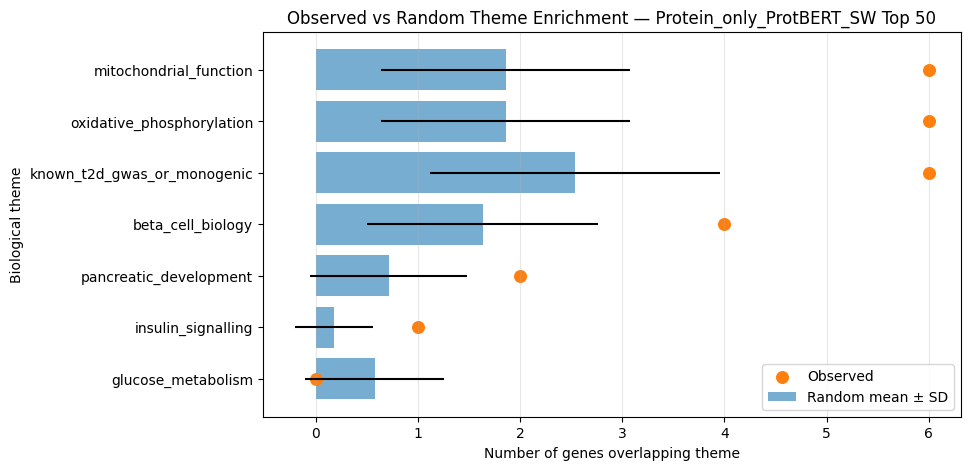

Saved: /content/drive/MyDrive/Project_Protein/model/phase12_random_gene_set_enrichment_baseline/figures/phase12_observed_vs_random_Protein_only_ProtBERT_SW_top50.png


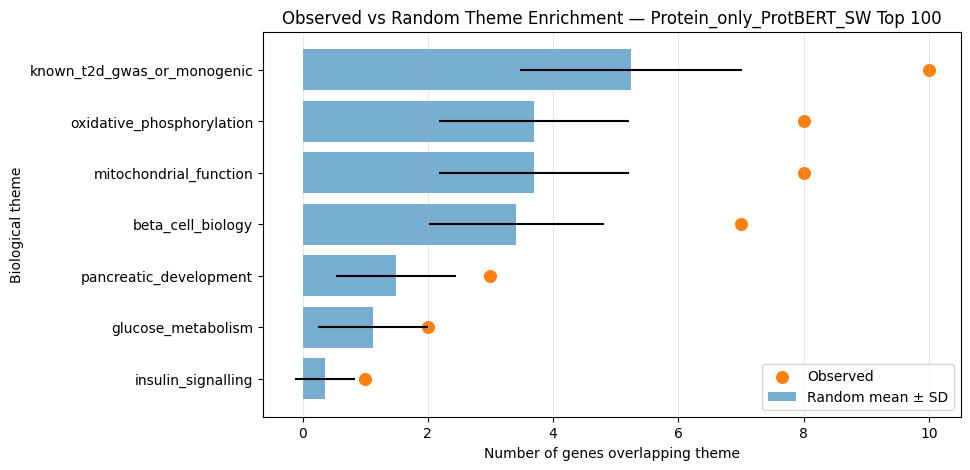

Saved: /content/drive/MyDrive/Project_Protein/model/phase12_random_gene_set_enrichment_baseline/figures/phase12_observed_vs_random_Protein_only_ProtBERT_SW_top100.png


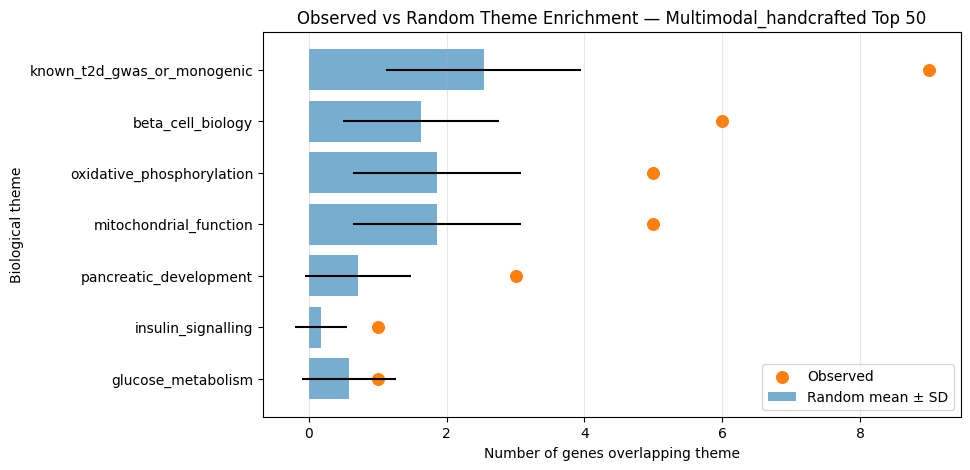

Saved: /content/drive/MyDrive/Project_Protein/model/phase12_random_gene_set_enrichment_baseline/figures/phase12_observed_vs_random_Multimodal_handcrafted_top50.png


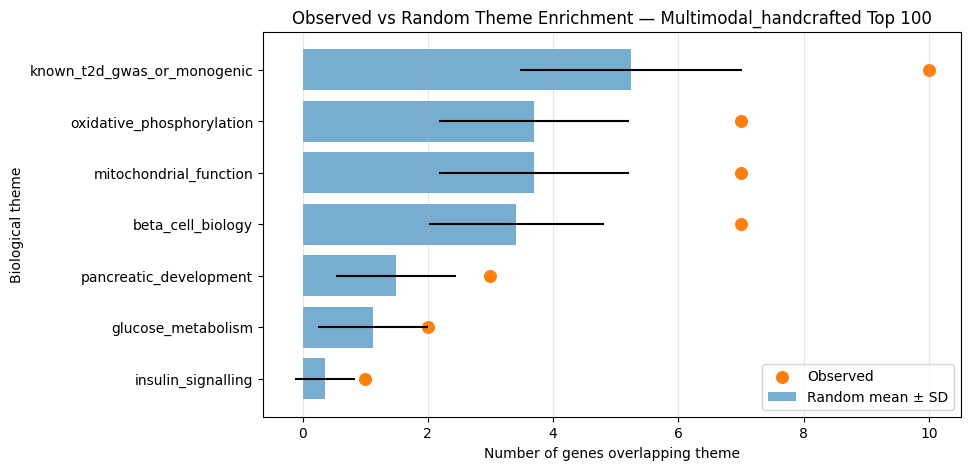

Saved: /content/drive/MyDrive/Project_Protein/model/phase12_random_gene_set_enrichment_baseline/figures/phase12_observed_vs_random_Multimodal_handcrafted_top100.png


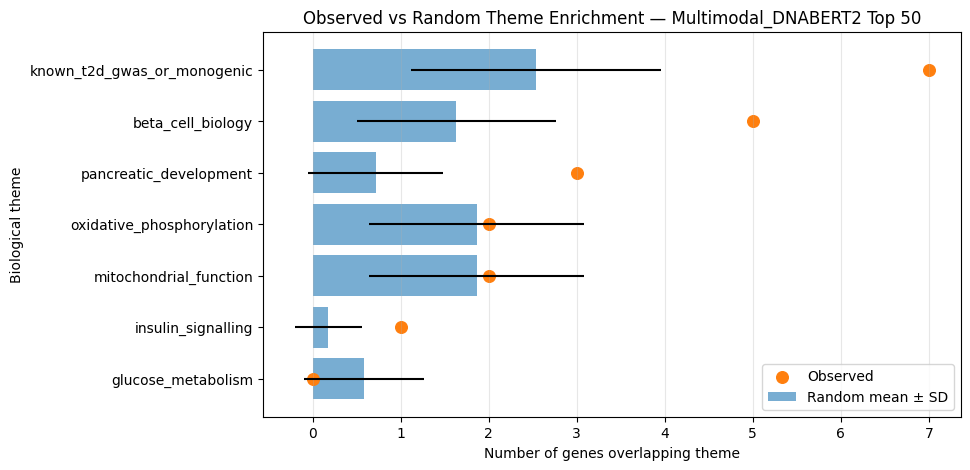

Saved: /content/drive/MyDrive/Project_Protein/model/phase12_random_gene_set_enrichment_baseline/figures/phase12_observed_vs_random_Multimodal_DNABERT2_top50.png


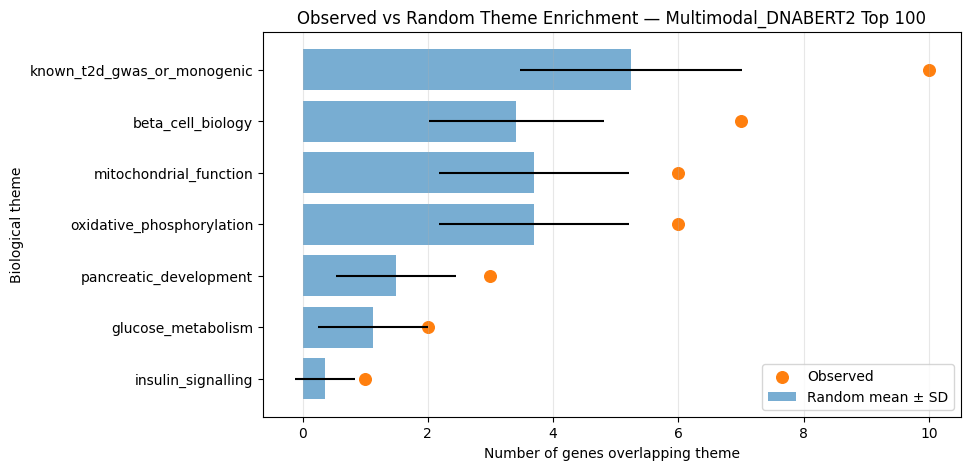

Saved: /content/drive/MyDrive/Project_Protein/model/phase12_random_gene_set_enrichment_baseline/figures/phase12_observed_vs_random_Multimodal_DNABERT2_top100.png


In [17]:
# ============================================================
# FIGURE 1 — OBSERVED VS RANDOM THEME COUNTS
# ============================================================

def plot_observed_vs_random(model_key, top_n, output_path):
    plot_df = fdr_df[
        (fdr_df["model_key"] == model_key) &
        (fdr_df["top_n"] == top_n) &
        (fdr_df["theme"].isin(MAIN_THEMES))
    ].copy()

    plot_df = plot_df.sort_values("observed_count", ascending=True)

    y = np.arange(len(plot_df))

    plt.figure(figsize=(9, 5))

    plt.barh(
        y,
        plot_df["random_mean"],
        xerr=plot_df["random_sd"],
        alpha=0.6,
        label="Random mean ± SD"
    )

    plt.scatter(
        plot_df["observed_count"],
        y,
        marker="o",
        s=70,
        label="Observed"
    )

    plt.yticks(y, plot_df["theme"])
    plt.xlabel("Number of genes overlapping theme")
    plt.ylabel("Biological theme")
    plt.title(f"Observed vs Random Theme Enrichment — {model_key} Top {top_n}")
    plt.legend()
    plt.grid(axis="x", alpha=0.3)

    plt.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.show()

    print("Saved:", output_path)


for model_key in MAIN_MODELS:
    for top_n in TOP_N_LIST:
        plot_observed_vs_random(
            model_key=model_key,
            top_n=top_n,
            output_path=FIGURE_DIR / f"phase12_observed_vs_random_{model_key}_top{top_n}.png"
        )

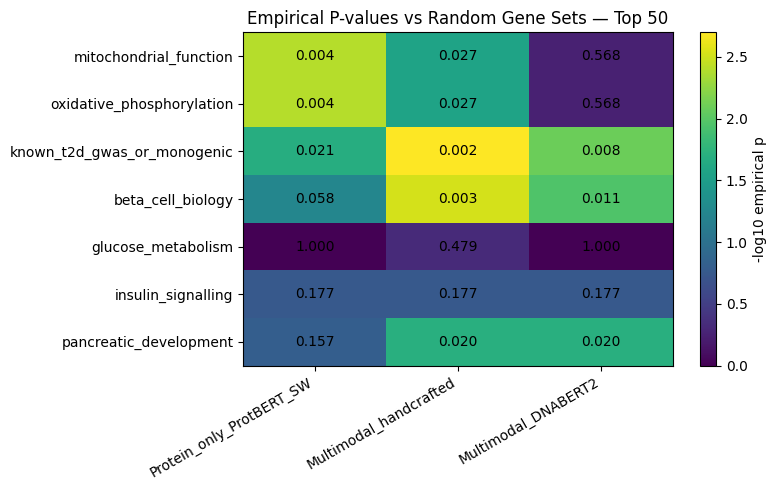

Saved: /content/drive/MyDrive/Project_Protein/model/phase12_random_gene_set_enrichment_baseline/figures/phase12_empirical_pvalue_heatmap_top50.png


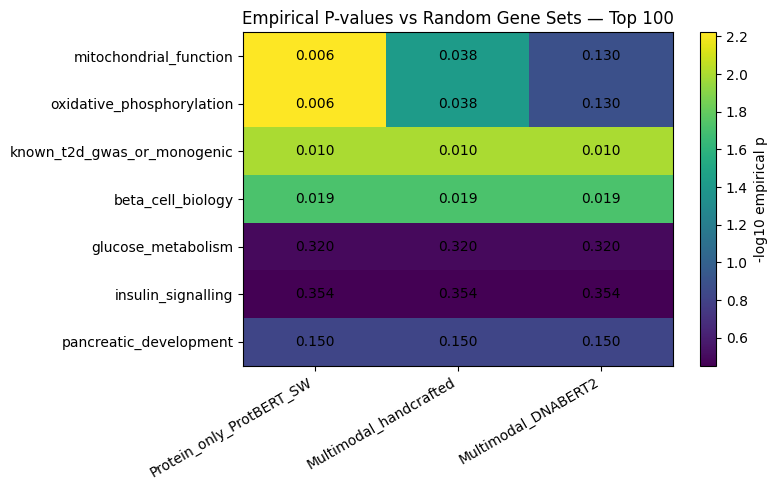

Saved: /content/drive/MyDrive/Project_Protein/model/phase12_random_gene_set_enrichment_baseline/figures/phase12_empirical_pvalue_heatmap_top100.png


In [18]:
# ============================================================
# FIGURE 2 — EMPIRICAL P-VALUE HEATMAP
# ============================================================

def plot_pvalue_heatmap(top_n, output_path):
    plot_df = focus_df[
        focus_df["top_n"] == top_n
    ].copy()

    pivot = plot_df.pivot_table(
        index="theme",
        columns="model_key",
        values="empirical_p_greater_equal",
        aggfunc="first"
    )

    pivot = pivot.loc[MAIN_THEMES, MAIN_MODELS]

    # Convert to -log10 p for visual clarity
    logp = -np.log10(pivot.astype(float).clip(lower=1e-6))

    plt.figure(figsize=(8, 5))
    plt.imshow(logp.values, aspect="auto")

    plt.xticks(np.arange(len(logp.columns)), logp.columns, rotation=30, ha="right")
    plt.yticks(np.arange(len(logp.index)), logp.index)

    for i in range(logp.shape[0]):
        for j in range(logp.shape[1]):
            p_val = pivot.values[i, j]
            plt.text(
                j, i,
                f"{p_val:.3f}",
                ha="center",
                va="center"
            )

    plt.colorbar(label="-log10 empirical p")
    plt.title(f"Empirical P-values vs Random Gene Sets — Top {top_n}")
    plt.tight_layout()

    plt.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.show()

    print("Saved:", output_path)


for top_n in TOP_N_LIST:
    plot_pvalue_heatmap(
        top_n=top_n,
        output_path=FIGURE_DIR / f"phase12_empirical_pvalue_heatmap_top{top_n}.png"
    )

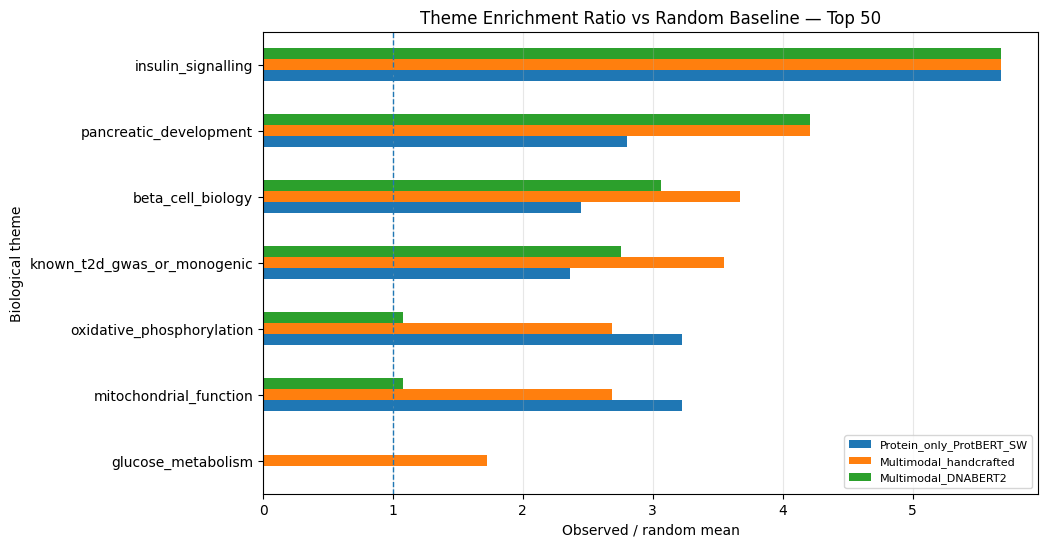

Saved: /content/drive/MyDrive/Project_Protein/model/phase12_random_gene_set_enrichment_baseline/figures/phase12_enrichment_ratio_top50.png


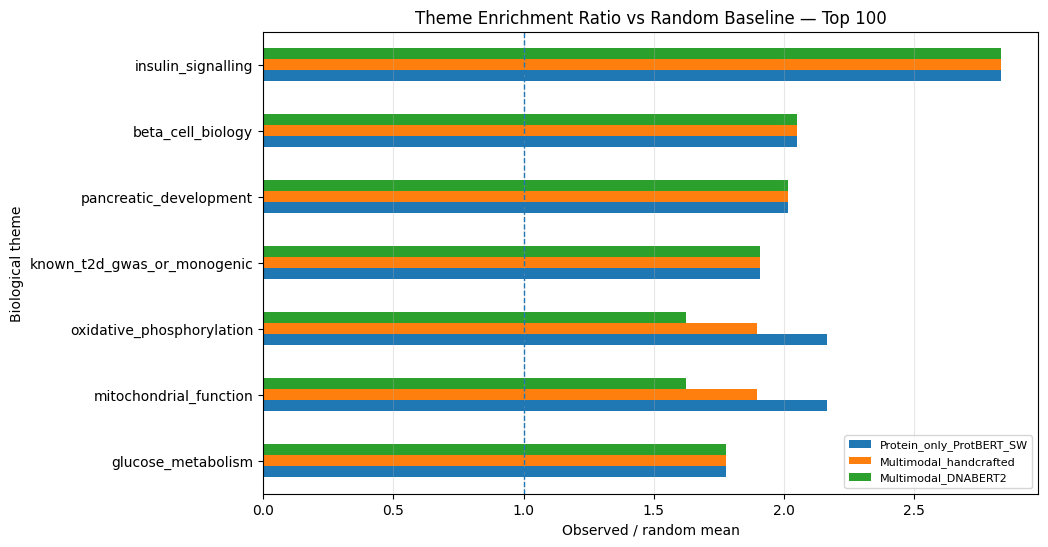

Saved: /content/drive/MyDrive/Project_Protein/model/phase12_random_gene_set_enrichment_baseline/figures/phase12_enrichment_ratio_top100.png


In [19]:
# ============================================================
# FIGURE 3 — ENRICHMENT RATIO COMPARISON
# ============================================================

def plot_enrichment_ratio(top_n, output_path):
    plot_df = focus_df[
        focus_df["top_n"] == top_n
    ].copy()

    pivot = plot_df.pivot_table(
        index="theme",
        columns="model_key",
        values="enrichment_ratio_vs_random_mean",
        aggfunc="first"
    )

    pivot = pivot.loc[MAIN_THEMES, MAIN_MODELS]

    pivot = pivot.loc[pivot.mean(axis=1).sort_values(ascending=True).index]

    pivot.plot(kind="barh", figsize=(10, 6))

    plt.axvline(1.0, linestyle="--", linewidth=1)
    plt.xlabel("Observed / random mean")
    plt.ylabel("Biological theme")
    plt.title(f"Theme Enrichment Ratio vs Random Baseline — Top {top_n}")
    plt.grid(axis="x", alpha=0.3)
    plt.legend(fontsize=8)

    plt.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.show()

    print("Saved:", output_path)


for top_n in TOP_N_LIST:
    plot_enrichment_ratio(
        top_n=top_n,
        output_path=FIGURE_DIR / f"phase12_enrichment_ratio_top{top_n}.png"
    )

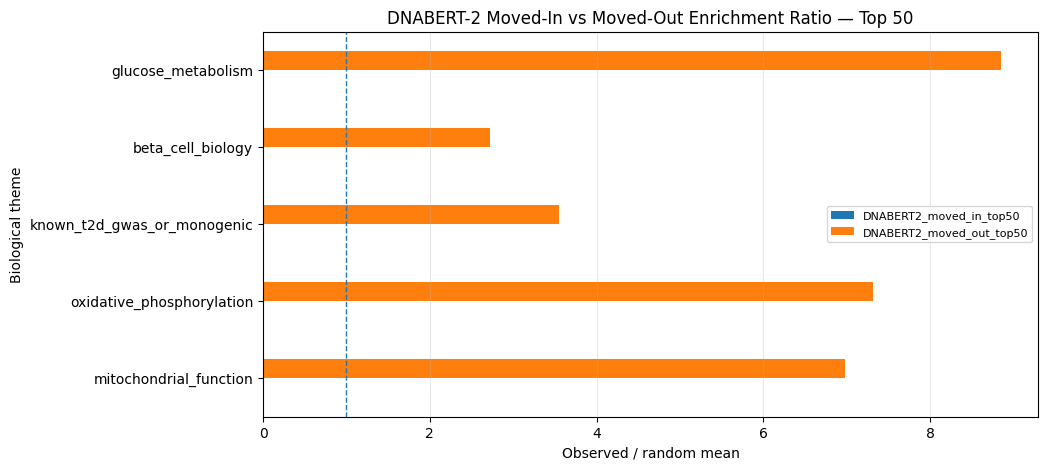

Saved: /content/drive/MyDrive/Project_Protein/model/phase12_random_gene_set_enrichment_baseline/figures/phase12_moved_in_out_enrichment_ratio_top50.png


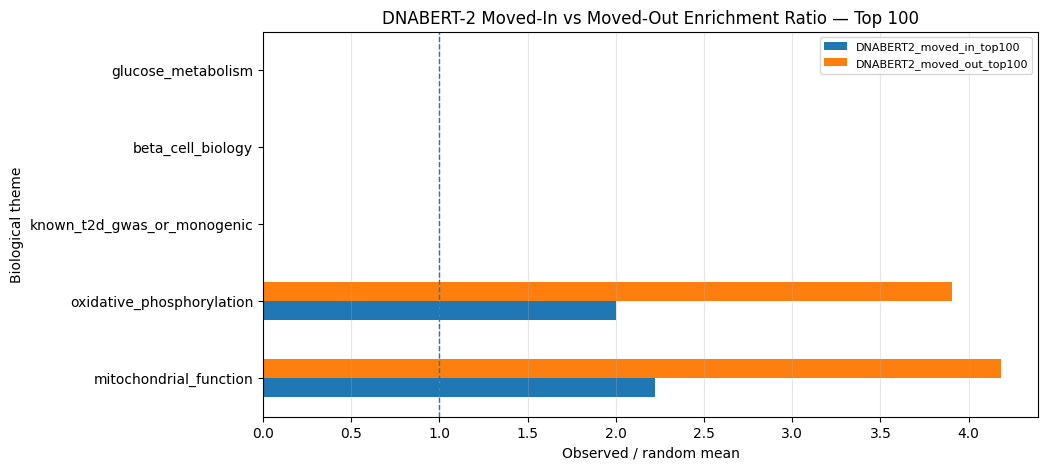

Saved: /content/drive/MyDrive/Project_Protein/model/phase12_random_gene_set_enrichment_baseline/figures/phase12_moved_in_out_enrichment_ratio_top100.png


In [20]:
# ============================================================
# FIGURE 4 — MOVED-IN VS MOVED-OUT RANDOM BASELINE
# ============================================================

moved_focus_themes = [
    "mitochondrial_function",
    "oxidative_phosphorylation",
    "known_t2d_gwas_or_monogenic",
    "beta_cell_biology",
    "glucose_metabolism"
]

for top_n in TOP_N_LIST:
    plot_df = moved_random_df[
        (moved_random_df["top_n"] == top_n) &
        (moved_random_df["theme"].isin(moved_focus_themes))
    ].copy()

    if plot_df.empty:
        continue

    pivot = plot_df.pivot_table(
        index="theme",
        columns="gene_set_name",
        values="enrichment_ratio_vs_random_mean",
        aggfunc="first"
    )

    pivot = pivot.loc[moved_focus_themes]

    pivot.plot(kind="barh", figsize=(10, 5))

    plt.axvline(1.0, linestyle="--", linewidth=1)
    plt.xlabel("Observed / random mean")
    plt.ylabel("Biological theme")
    plt.title(f"DNABERT-2 Moved-In vs Moved-Out Enrichment Ratio — Top {top_n}")
    plt.grid(axis="x", alpha=0.3)
    plt.legend(fontsize=8)

    out_path = FIGURE_DIR / f"phase12_moved_in_out_enrichment_ratio_top{top_n}.png"
    plt.savefig(out_path, dpi=300, bbox_inches="tight")
    plt.show()

    print("Saved:", out_path)

In [21]:
# ============================================================
# PHASE 12 FINAL INTERPRETATION CLAIMS
# ============================================================

def get_focus_row(model_key, top_n, theme):
    sub = fdr_df[
        (fdr_df["model_key"] == model_key) &
        (fdr_df["top_n"] == top_n) &
        (fdr_df["theme"] == theme)
    ]
    if sub.empty:
        return None
    return sub.iloc[0]


claims = []

# Key theme checks
for model_key in ["Multimodal_handcrafted", "Multimodal_DNABERT2", "Protein_only_ProtBERT_SW"]:
    for top_n in [100]:
        for theme in ["mitochondrial_function", "oxidative_phosphorylation", "known_t2d_gwas_or_monogenic", "beta_cell_biology"]:
            row = get_focus_row(model_key, top_n, theme)

            if row is None:
                continue

            claims.append({
                "claim_area": f"{model_key} top{top_n} {theme}",
                "observed_count": int(row["observed_count"]),
                "random_mean": row["random_mean"],
                "random_sd": row["random_sd"],
                "enrichment_ratio": row["enrichment_ratio_vs_random_mean"],
                "empirical_p": row["empirical_p_greater_equal"],
                "fdr_p": row["empirical_p_bh_fdr"],
                "interpretation": (
                    "Observed theme concentration is stronger than random baseline."
                    if row["empirical_p_greater_equal"] < 0.05 else
                    "Observed theme concentration is not clearly stronger than random baseline."
                )
            })

phase12_claims_df = pd.DataFrame(claims)
phase12_claims_df = round_numeric_columns(phase12_claims_df, 4)

display(phase12_claims_df)

claims_path = RESULT_DIR / "phase12_final_interpretation_claims.csv"
phase12_claims_df.to_csv(claims_path, index=False)

print("Saved:", claims_path)

,claim_area,observed_count,random_mean,random_sd,enrichment_ratio,empirical_p,fdr_p,interpretation
0,Multimodal_handcrafted top100 mitochondrial_function,7,3.694,1.5161,1.8950,0.0380,0.1158,Observed theme concentration is stronger than random baseline.
1,Multimodal_handcrafted top100 oxidative_phosphorylation,7,3.694,1.5161,1.8950,0.0380,0.1158,Observed theme concentration is stronger than random baseline.
2,Multimodal_handcrafted top100 known_t2d_gwas_or_monogenic,10,5.241,1.7709,1.9080,0.0100,0.0640,Observed theme concentration is stronger than random baseline.
3,Multimodal_handcrafted top100 beta_cell_biology,7,3.413,1.3958,2.0510,0.0190,0.0791,Observed theme concentration is stronger than random baseline.
4,Multimodal_DNABERT2 top100 mitochondrial_function,6,3.694,1.5161,1.6243,0.1299,0.3058,Observed theme concentration is not clearly stronger than random baseline.
5,Multimodal_DNABERT2 top100 oxidative_phosphorylation,6,3.694,1.5161,1.6243,0.1299,0.3058,Observed theme concentration is not clearly stronger than random baseline.
6,Multimodal_DNABERT2 top100 known_t2d_gwas_or_monogenic,10,5.241,1.7709,1.9080,0.0100,0.0640,Observed theme concentration is stronger than random baseline.
7,Multimodal_DNABERT2 top100 beta_cell_biology,7,3.413,1.3958,2.0510,0.0190,0.0791,Observed theme concentration is stronger than random baseline.
8,Protein_only_ProtBERT_SW top100 mitochondrial_function,8,3.694,1.5161,2.1657,0.0060,0.0640,Observed theme concentration is stronger than random baseline.
9,Protein_only_ProtBERT_SW top100 oxidative_phosphorylation,8,3.694,1.5161,2.1657,0.0060,0.0640,Observed theme concentration is stronger than random baseline.


Saved: /content/drive/MyDrive/Project_Protein/model/phase12_random_gene_set_enrichment_baseline/results/phase12_final_interpretation_claims.csv


In [22]:
# ============================================================
# PHASE 12 REPRODUCIBILITY TABLE
# ============================================================

reproducibility_df = pd.DataFrame([
    {
        "item": "Candidate universe",
        "value": f"{len(universe_genes)} genes from final ranked prediction tables",
        "note": "Random sets were sampled from the same candidate universe as model top-ranked genes."
    },
    {
        "item": "Random permutations",
        "value": str(N_RANDOM_PERMUTATIONS),
        "note": "Used for curated biological theme random baseline."
    },
    {
        "item": "Random seed",
        "value": str(RANDOM_SEED),
        "note": "Used for reproducible random gene-set sampling."
    },
    {
        "item": "Top-N sizes",
        "value": ", ".join([str(x) for x in TOP_N_LIST]),
        "note": "Observed top-ranked gene lists tested against same-size random gene sets."
    },
    {
        "item": "Empirical p-value",
        "value": "P(random count >= observed count)",
        "note": "Plus-one correction used to avoid zero empirical p-values."
    },
    {
        "item": "Multiple comparison correction",
        "value": "Benjamini-Hochberg FDR",
        "note": "Applied across observed model/top/theme tests."
    },
    {
        "item": "Primary biological themes",
        "value": "; ".join(MAIN_THEMES),
        "note": "Themes align with Phase 8/9 biological validation."
    },
    {
        "item": "Optional g:Profiler baseline",
        "value": str(RUN_GPROFILER_RANDOM_BASELINE),
        "note": "Curated-theme baseline is primary because it is reproducible and not API-dependent."
    }
])

display(reproducibility_df)

reproducibility_path = RESULT_DIR / "phase12_reproducibility_table.csv"
reproducibility_df.to_csv(reproducibility_path, index=False)

print("Saved:", reproducibility_path)

,item,value,note
0,Candidate universe,271 genes from final ranked prediction tables,Random sets were sampled from the same candidate universe as model top-ranked genes.
1,Random permutations,1000,Used for curated biological theme random baseline.
2,Random seed,42,Used for reproducible random gene-set sampling.
3,Top-N sizes,"50, 100",Observed top-ranked gene lists tested against same-size random gene sets.
4,Empirical p-value,P(random count >= observed count),Plus-one correction used to avoid zero empirical p-values.
5,Multiple comparison correction,Benjamini-Hochberg FDR,Applied across observed model/top/theme tests.
6,Primary biological themes,mitochondrial_function; oxidative_phosphorylation; known_t2d_gwas_or_monogenic; beta_cell_biology; glucose_metabolism; insulin_signalling; pancreatic_development,Themes align with Phase 8/9 biological validation.
7,Optional g:Profiler baseline,False,Curated-theme baseline is primary because it is reproducible and not API-dependent.


Saved: /content/drive/MyDrive/Project_Protein/model/phase12_random_gene_set_enrichment_baseline/results/phase12_reproducibility_table.csv


In [23]:
# ============================================================
# EXPORT PHASE 12 EXCEL WORKBOOK
# ============================================================

excel_path = EXCEL_DIR / "phase12_random_gene_set_enrichment_baseline_tables.xlsx"

excel_tables = {
    "Observed_vs_Random_FDR": fdr_df,
    "Focus_Main_Themes": focus_df,
    "Publication_Table": compact_publication_df,
    "Hand_vs_DNABERT2": hand_vs_dna_random_df,
    "Moved_In_Out_Random": moved_random_df,
    "Universe_Composition": universe_theme_df,
    "Observed_Top_Themes": observed_top_theme_df,
    "Phase12_Claims": phase12_claims_df,
    "Reproducibility": reproducibility_df,
}

if "gprofiler_baseline_df" in globals():
    excel_tables["Optional_gProfiler"] = gprofiler_baseline_df

with pd.ExcelWriter(excel_path, engine="openpyxl") as writer:
    for sheet_name, df in excel_tables.items():
        df.to_excel(writer, sheet_name=sheet_name[:31], index=False)

print("Saved Excel:", excel_path)

Saved Excel: /content/drive/MyDrive/Project_Protein/model/phase12_random_gene_set_enrichment_baseline/excel/phase12_random_gene_set_enrichment_baseline_tables.xlsx


In [24]:
# ============================================================
# AUTO-GENERATE PHASE 12 REPORT SUMMARY
# ============================================================

def report_theme_sentence(model_key, top_n, theme):
    row = get_focus_row(model_key, top_n, theme)
    if row is None:
        return f"- {model_key} top{top_n} {theme}: not available."

    return (
        f"- {model_key} top{top_n} {theme}: observed={int(row['observed_count'])}, "
        f"random mean={row['random_mean']:.2f} ± {row['random_sd']:.2f}, "
        f"enrichment ratio={row['enrichment_ratio_vs_random_mean']:.2f}, "
        f"empirical p={row['empirical_p_greater_equal']:.4f}, "
        f"FDR p={row['empirical_p_bh_fdr']:.4f}."
    )

report_lines = []

report_lines.append("# Phase 12 — Random-Gene-Set Biological Enrichment Baseline")
report_lines.append("")
report_lines.append("## Objective")
report_lines.append("")
report_lines.append(
    "Phase 12 addressed the reviewer-relevant concern that the observed biological enrichment "
    "in top-ranked genes may arise by chance due to list size or candidate-universe composition. "
    "To test this, observed model top-50 and top-100 gene lists were compared against random gene sets "
    "of the same size sampled from the same candidate universe."
)
report_lines.append("")
report_lines.append("## Experimental Design")
report_lines.append("")
report_lines.append(f"- Candidate universe size: {len(universe_genes)} genes.")
report_lines.append(f"- Number of random permutations: {N_RANDOM_PERMUTATIONS}.")
report_lines.append(f"- Top-N list sizes tested: {TOP_N_LIST}.")
report_lines.append(f"- Random seed: {RANDOM_SEED}.")
report_lines.append("- Empirical p-value: proportion of random sets with theme count greater than or equal to the observed model count.")
report_lines.append("- Multiple comparison correction: Benjamini-Hochberg FDR.")
report_lines.append("")
report_lines.append("## Key Results: Main Top-100 Biological Themes")
report_lines.append("")

for model_key in MAIN_MODELS:
    report_lines.append(f"### {model_key}")
    for theme in [
        "mitochondrial_function",
        "oxidative_phosphorylation",
        "known_t2d_gwas_or_monogenic",
        "beta_cell_biology",
        "glucose_metabolism",
        "insulin_signalling",
        "pancreatic_development"
    ]:
        report_lines.append(report_theme_sentence(model_key, 100, theme))
    report_lines.append("")

report_lines.append("## Handcrafted vs DNABERT-2 Interpretation")
report_lines.append("")
report_lines.append(
    "This random baseline should be used to determine whether the stronger biological interpretation "
    "of the handcrafted multimodal model is supported beyond random expectation. If handcrafted top-ranked "
    "genes show higher mitochondrial/OXPHOS enrichment ratios or lower empirical p-values than DNABERT-2, "
    "this supports the ranking-versus-interpretability trade-off: DNABERT-2 improves global ranking while "
    "handcrafted genomic features preserve more pathway-specific biological concentration."
)
report_lines.append("")
report_lines.append("## Reviewer-Relevant Contribution")
report_lines.append("")
report_lines.append(
    "This phase directly addresses the concern that enrichment may be an artefact of random list composition. "
    "By sampling same-size random gene sets from the same candidate universe, the analysis provides an empirical "
    "baseline for evaluating whether observed OXPHOS, mitochondrial, beta-cell, glucose, and known T2D theme "
    "concentrations are stronger than expected by chance."
)

report_text = "\n".join(report_lines)

report_path = REPORT_DIR / "phase12_random_gene_set_enrichment_baseline_summary.md"

with open(report_path, "w") as f:
    f.write(report_text)

print(report_text)
print("\nSaved:", report_path)

# Phase 12 — Random-Gene-Set Biological Enrichment Baseline

## Objective

Phase 12 addressed the reviewer-relevant concern that the observed biological enrichment in top-ranked genes may arise by chance due to list size or candidate-universe composition. To test this, observed model top-50 and top-100 gene lists were compared against random gene sets of the same size sampled from the same candidate universe.

## Experimental Design

- Candidate universe size: 271 genes.
- Number of random permutations: 1000.
- Top-N list sizes tested: [50, 100].
- Random seed: 42.
- Empirical p-value: proportion of random sets with theme count greater than or equal to the observed model count.
- Multiple comparison correction: Benjamini-Hochberg FDR.

## Key Results: Main Top-100 Biological Themes

### Protein_only_ProtBERT_SW
- Protein_only_ProtBERT_SW top100 mitochondrial_function: observed=8, random mean=3.69 ± 1.52, enrichment ratio=2.17, empirical p=0.0060, FDR p=0.0640.
- Protein_only_ProtBERT_S

In [25]:
# ============================================================
# LIST PHASE 12 OUTPUTS
# ============================================================

print("=== RESULT FILES ===")
for p in sorted(RESULT_DIR.glob("*")):
    print(p)

print("\n=== FIGURE FILES ===")
for p in sorted(FIGURE_DIR.glob("*")):
    print(p)

print("\n=== EXCEL FILES ===")
for p in sorted(EXCEL_DIR.glob("*")):
    print(p)

print("\n=== REPORT FILES ===")
for p in sorted(REPORT_DIR.glob("*")):
    print(p)

print("\n=== GENE LIST FILES ===")
for p in sorted(GENE_LIST_DIR.glob("*"))[:40]:
    print(p)

if len(list(GENE_LIST_DIR.glob("*"))) > 40:
    print("... more gene list files omitted")

=== RESULT FILES ===
/content/drive/MyDrive/Project_Protein/model/phase12_random_gene_set_enrichment_baseline/results/phase12_candidate_universe_theme_composition.csv
/content/drive/MyDrive/Project_Protein/model/phase12_random_gene_set_enrichment_baseline/results/phase12_dnabert2_moved_in_out_random_baseline.csv
/content/drive/MyDrive/Project_Protein/model/phase12_random_gene_set_enrichment_baseline/results/phase12_final_interpretation_claims.csv
/content/drive/MyDrive/Project_Protein/model/phase12_random_gene_set_enrichment_baseline/results/phase12_focus_observed_vs_random_main_models_themes.csv
/content/drive/MyDrive/Project_Protein/model/phase12_random_gene_set_enrichment_baseline/results/phase12_handcrafted_vs_dnabert2_random_baseline_comparison.csv
/content/drive/MyDrive/Project_Protein/model/phase12_random_gene_set_enrichment_baseline/results/phase12_observed_topN_theme_overlap.csv
/content/drive/MyDrive/Project_Protein/model/phase12_random_gene_set_enrichment_baseline/results/ph

In [26]:
display(compact_publication_df)
display(focus_df)
display(hand_vs_dna_random_df)
display(moved_random_df)
display(phase12_claims_df)
display(reproducibility_df)

,Model,Top N,Theme,Observed,Random mean ± SD,Random 95% interval,Enrichment ratio,Empirical p,FDR p,Observed genes
0,Multimodal_DNABERT2,50,beta_cell_biology,5,1.63 ± 1.13,0.0–4.0,3.0618,0.0110,0.0640,CACNA1D;GAD1;ISL1;NEUROD1;PDX1
1,Multimodal_handcrafted,50,beta_cell_biology,6,1.63 ± 1.13,0.0–4.0,3.6742,0.0030,0.0640,CACNA1D;DPP4;GAD1;ISL1;NEUROD1;PDX1
2,Protein_only_ProtBERT_SW,50,beta_cell_biology,4,1.63 ± 1.13,0.0–4.0,2.4495,0.0579,0.1611,CACNA1D;GAD1;ISL1;NEUROD1
3,Multimodal_DNABERT2,50,glucose_metabolism,0,0.58 ± 0.68,0.0–2.0,0.0000,1.0000,1.0000,
4,Multimodal_handcrafted,50,glucose_metabolism,1,0.58 ± 0.68,0.0–2.0,1.7271,0.4795,0.5902,SLC5A1
5,Protein_only_ProtBERT_SW,50,glucose_metabolism,0,0.58 ± 0.68,0.0–2.0,0.0000,1.0000,1.0000,
6,Multimodal_DNABERT2,50,insulin_signalling,1,0.18 ± 0.38,0.0–1.0,5.6818,0.1768,0.3058,INSR
7,Multimodal_handcrafted,50,insulin_signalling,1,0.18 ± 0.38,0.0–1.0,5.6818,0.1768,0.3058,INSR
8,Protein_only_ProtBERT_SW,50,insulin_signalling,1,0.18 ± 0.38,0.0–1.0,5.6818,0.1768,0.3058,INSR
9,Multimodal_DNABERT2,50,known_t2d_gwas_or_monogenic,7,2.54 ± 1.42,0.0–5.0,2.7592,0.0080,0.0640,CACNA1D;GAD1;HHEX;IGF2BP2;INSR;NEUROD1;PDX1


,model_key,top_n,theme,observed_count,observed_fraction,observed_genes,random_mean,random_sd,random_median,random_min,random_max,random_p025,random_p975,z_score_vs_random,enrichment_ratio_vs_random_mean,empirical_p_greater_equal,significant_empirical_p_0p05,n_random_permutations,universe_size,empirical_p_bh_fdr,significant_fdr_0p05
0,Multimodal_DNABERT2,50,beta_cell_biology,5,0.10,CACNA1D;GAD1;ISL1;NEUROD1;PDX1,1.633,1.1312,2.0,0,6,0.0,4.0,2.9765,3.0618,0.0110,True,1000,271,0.0640,False
1,Multimodal_handcrafted,50,beta_cell_biology,6,0.12,CACNA1D;DPP4;GAD1;ISL1;NEUROD1;PDX1,1.633,1.1312,2.0,0,6,0.0,4.0,3.8605,3.6742,0.0030,True,1000,271,0.0640,False
2,Protein_only_ProtBERT_SW,50,beta_cell_biology,4,0.08,CACNA1D;GAD1;ISL1;NEUROD1,1.633,1.1312,2.0,0,6,0.0,4.0,2.0925,2.4495,0.0579,False,1000,271,0.1611,False
3,Multimodal_DNABERT2,50,glucose_metabolism,0,0.00,,0.579,0.6813,0.0,0,3,0.0,2.0,-0.8498,0.0000,1.0000,False,1000,271,1.0000,False
4,Multimodal_handcrafted,50,glucose_metabolism,1,0.02,SLC5A1,0.579,0.6813,0.0,0,3,0.0,2.0,0.6179,1.7271,0.4795,False,1000,271,0.5902,False
5,Protein_only_ProtBERT_SW,50,glucose_metabolism,0,0.00,,0.579,0.6813,0.0,0,3,0.0,2.0,-0.8498,0.0000,1.0000,False,1000,271,1.0000,False
6,Multimodal_DNABERT2,50,insulin_signalling,1,0.02,INSR,0.176,0.3810,0.0,0,1,0.0,1.0,2.1627,5.6818,0.1768,False,1000,271,0.3058,False
7,Multimodal_handcrafted,50,insulin_signalling,1,0.02,INSR,0.176,0.3810,0.0,0,1,0.0,1.0,2.1627,5.6818,0.1768,False,1000,271,0.3058,False
8,Protein_only_ProtBERT_SW,50,insulin_signalling,1,0.02,INSR,0.176,0.3810,0.0,0,1,0.0,1.0,2.1627,5.6818,0.1768,False,1000,271,0.3058,False
9,Multimodal_DNABERT2,50,known_t2d_gwas_or_monogenic,7,0.14,CACNA1D;GAD1;HHEX;IGF2BP2;INSR;NEUROD1;PDX1,2.537,1.4159,2.0,0,9,0.0,5.0,3.1522,2.7592,0.0080,True,1000,271,0.0640,False


,top_n,theme,handcrafted_observed,dnabert2_observed,delta_dnabert2_minus_handcrafted_observed,handcrafted_empirical_p,dnabert2_empirical_p,handcrafted_fdr_p,dnabert2_fdr_p,handcrafted_enrichment_ratio,dnabert2_enrichment_ratio,delta_dnabert2_minus_handcrafted_enrichment_ratio,interpretation
0,50,mitochondrial_function,5,2,-3,0.0270,0.5684,0.0909,0.6737,2.6867,1.0747,-1.6120,Handcrafted has stronger observed theme concentration.
1,50,oxidative_phosphorylation,5,2,-3,0.0270,0.5684,0.0909,0.6737,2.6867,1.0747,-1.6120,Handcrafted has stronger observed theme concentration.
2,50,known_t2d_gwas_or_monogenic,9,7,-2,0.0020,0.0080,0.0640,0.0640,3.5475,2.7592,-0.7883,Handcrafted has stronger observed theme concentration.
3,50,beta_cell_biology,6,5,-1,0.0030,0.0110,0.0640,0.0640,3.6742,3.0618,-0.6124,Handcrafted has stronger observed theme concentration.
4,50,glucose_metabolism,1,0,-1,0.4795,1.0000,0.5902,1.0000,1.7271,0.0000,-1.7271,Handcrafted has stronger observed theme concentration.
5,50,insulin_signalling,1,1,0,0.1768,0.1768,0.3058,0.3058,5.6818,5.6818,0.0000,Both models have equal observed theme concentration.
6,50,pancreatic_development,3,3,0,0.0200,0.0200,0.0791,0.0791,4.2076,4.2076,0.0000,Both models have equal observed theme concentration.
7,100,mitochondrial_function,7,6,-1,0.0380,0.1299,0.1158,0.3058,1.8950,1.6243,-0.2707,Handcrafted has stronger observed theme concentration.
8,100,oxidative_phosphorylation,7,6,-1,0.0380,0.1299,0.1158,0.3058,1.8950,1.6243,-0.2707,Handcrafted has stronger observed theme concentration.
9,100,known_t2d_gwas_or_monogenic,10,10,0,0.0100,0.0100,0.0640,0.0640,1.9080,1.9080,0.0000,Both models have equal observed theme concentration.


,gene_set_name,top_n,set_size,theme,observed_count,observed_fraction,observed_genes,random_mean,random_sd,random_median,random_min,random_max,random_p025,random_p975,z_score_vs_random,enrichment_ratio_vs_random_mean,empirical_p_greater_equal,significant_empirical_p_0p05,n_random_permutations,empirical_p_bh_fdr,significant_fdr_0p05
0,DNABERT2_moved_in_top50,50,11,insulin_signalling,0,0.0000,,0.039,0.1937,0.0,0,1,0.0,1.0,-0.2014,0.0000,1.0000,False,1000,1.0000,False
1,DNABERT2_moved_in_top50,50,11,glucose_metabolism,0,0.0000,,0.123,0.3435,0.0,0,2,0.0,1.0,-0.3581,0.0000,1.0000,False,1000,1.0000,False
2,DNABERT2_moved_in_top50,50,11,beta_cell_biology,0,0.0000,,0.378,0.5912,0.0,0,4,0.0,2.0,-0.6394,0.0000,1.0000,False,1000,1.0000,False
3,DNABERT2_moved_in_top50,50,11,mitochondrial_function,0,0.0000,,0.414,0.6124,0.0,0,4,0.0,2.0,-0.6761,0.0000,1.0000,False,1000,1.0000,False
4,DNABERT2_moved_in_top50,50,11,oxidative_phosphorylation,0,0.0000,,0.411,0.6168,0.0,0,4,0.0,2.0,-0.6663,0.0000,1.0000,False,1000,1.0000,False
5,DNABERT2_moved_in_top50,50,11,pancreatic_development,0,0.0000,,0.149,0.3807,0.0,0,2,0.0,1.0,-0.3914,0.0000,1.0000,False,1000,1.0000,False
6,DNABERT2_moved_in_top50,50,11,lipid_metabolism,0,0.0000,,0.033,0.1787,0.0,0,1,0.0,1.0,-0.1846,0.0000,1.0000,False,1000,1.0000,False
7,DNABERT2_moved_in_top50,50,11,known_t2d_gwas_or_monogenic,0,0.0000,,0.578,0.7116,0.0,0,4,0.0,2.0,-0.8122,0.0000,1.0000,False,1000,1.0000,False
8,DNABERT2_moved_out_top50,50,11,insulin_signalling,0,0.0000,,0.042,0.2007,0.0,0,1,0.0,1.0,-0.2093,0.0000,1.0000,False,1000,1.0000,False
9,DNABERT2_moved_out_top50,50,11,glucose_metabolism,1,0.0909,SLC5A1,0.113,0.3322,0.0,0,2,0.0,1.0,2.6703,8.8496,0.1089,False,1000,0.5808,False


,claim_area,observed_count,random_mean,random_sd,enrichment_ratio,empirical_p,fdr_p,interpretation
0,Multimodal_handcrafted top100 mitochondrial_function,7,3.694,1.5161,1.8950,0.0380,0.1158,Observed theme concentration is stronger than random baseline.
1,Multimodal_handcrafted top100 oxidative_phosphorylation,7,3.694,1.5161,1.8950,0.0380,0.1158,Observed theme concentration is stronger than random baseline.
2,Multimodal_handcrafted top100 known_t2d_gwas_or_monogenic,10,5.241,1.7709,1.9080,0.0100,0.0640,Observed theme concentration is stronger than random baseline.
3,Multimodal_handcrafted top100 beta_cell_biology,7,3.413,1.3958,2.0510,0.0190,0.0791,Observed theme concentration is stronger than random baseline.
4,Multimodal_DNABERT2 top100 mitochondrial_function,6,3.694,1.5161,1.6243,0.1299,0.3058,Observed theme concentration is not clearly stronger than random baseline.
5,Multimodal_DNABERT2 top100 oxidative_phosphorylation,6,3.694,1.5161,1.6243,0.1299,0.3058,Observed theme concentration is not clearly stronger than random baseline.
6,Multimodal_DNABERT2 top100 known_t2d_gwas_or_monogenic,10,5.241,1.7709,1.9080,0.0100,0.0640,Observed theme concentration is stronger than random baseline.
7,Multimodal_DNABERT2 top100 beta_cell_biology,7,3.413,1.3958,2.0510,0.0190,0.0791,Observed theme concentration is stronger than random baseline.
8,Protein_only_ProtBERT_SW top100 mitochondrial_function,8,3.694,1.5161,2.1657,0.0060,0.0640,Observed theme concentration is stronger than random baseline.
9,Protein_only_ProtBERT_SW top100 oxidative_phosphorylation,8,3.694,1.5161,2.1657,0.0060,0.0640,Observed theme concentration is stronger than random baseline.


,item,value,note
0,Candidate universe,271 genes from final ranked prediction tables,Random sets were sampled from the same candidate universe as model top-ranked genes.
1,Random permutations,1000,Used for curated biological theme random baseline.
2,Random seed,42,Used for reproducible random gene-set sampling.
3,Top-N sizes,"50, 100",Observed top-ranked gene lists tested against same-size random gene sets.
4,Empirical p-value,P(random count >= observed count),Plus-one correction used to avoid zero empirical p-values.
5,Multiple comparison correction,Benjamini-Hochberg FDR,Applied across observed model/top/theme tests.
6,Primary biological themes,mitochondrial_function; oxidative_phosphorylation; known_t2d_gwas_or_monogenic; beta_cell_biology; glucose_metabolism; insulin_signalling; pancreatic_development,Themes align with Phase 8/9 biological validation.
7,Optional g:Profiler baseline,False,Curated-theme baseline is primary because it is reproducible and not API-dependent.
